In [1]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


In [2]:
#importing data from kaggle
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df = df.drop("Time", axis=1)

In [4]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()

In [5]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()

In [6]:
#standard scaling
df['std_Amount'] = scaler.fit_transform(df['Amount'].values.reshape (-1,1))

#removing Amount
df = df.drop("Amount", axis=1)

<Axes: xlabel='Class', ylabel='count'>

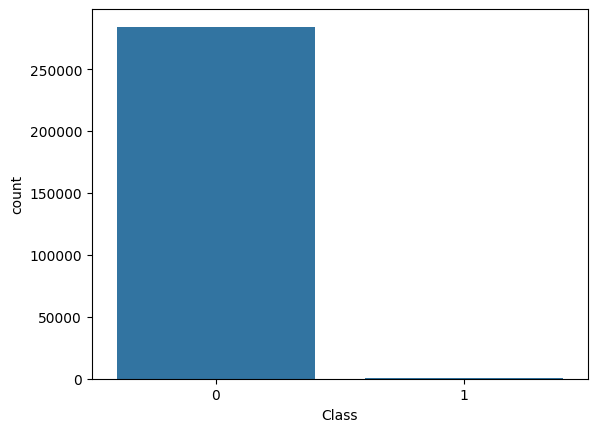

In [7]:
sns.countplot(x="Class", data=df)

In [9]:
import imblearn
from imblearn.under_sampling import RandomUnderSampler 

undersample = RandomUnderSampler(sampling_strategy=0.5)

In [10]:
cols = df.columns.tolist()
cols = [c for c in cols if c not in ["Class"]]
target = "Class"

In [11]:
#define X and Y
X = df[cols]
Y = df[target]

#undersample
X_under, Y_under = undersample.fit_resample(X, Y)

In [12]:
from pandas import DataFrame
test = pd.DataFrame(Y_under, columns = ['Class'])

Text(0.5, 1.0, 'After')

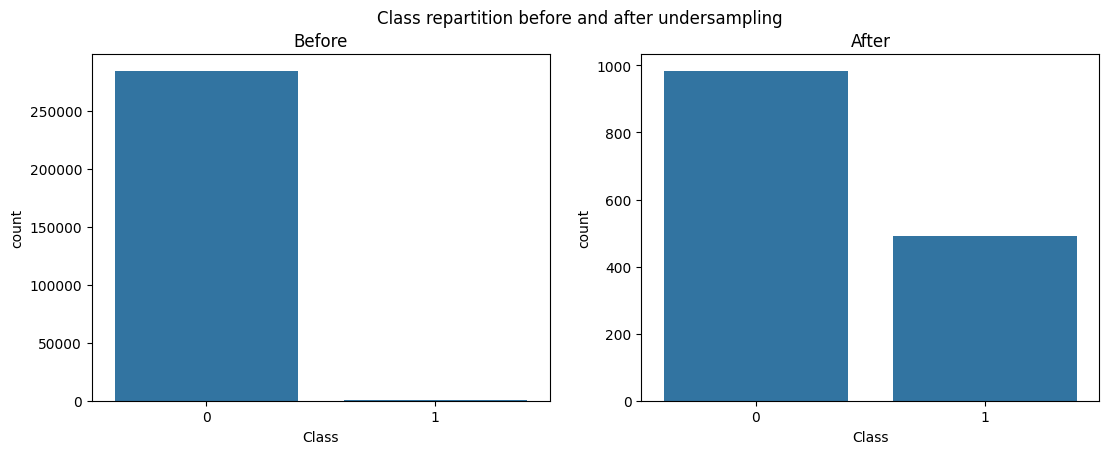

In [13]:
#visualizing undersampling results
fig, axs = plt.subplots(ncols=2, figsize=(13,4.5))
sns.countplot(x="Class", data=df, ax=axs[0])
sns.countplot(x="Class", data=test, ax=axs[1])

fig.suptitle("Class repartition before and after undersampling")
a1=fig.axes[0]
a1.set_title("Before")
a2=fig.axes[1]
a2.set_title("After")

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_under, Y_under, test_size=0.2, random_state=1)

In [15]:
#importing packages for modeling
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.layers import Dropout
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import BatchNormalization

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load your data
df = pd.read_csv('creditcard.csv')

# Define your features (X) and target (y)
X = df.drop('Class', axis=1) # Assuming 'Class' is your target
y = df['Class']

In [17]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Now, this cell will work correctly
model1 = LogisticRegression(random_state=2)
logit = model1.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Create a scaler object
scaler = StandardScaler()

# 2. Fit the scaler on the TRAINING data and transform it
#    Use fit_transform on the training data so the scaler learns the data's properties
X_train_scaled = scaler.fit_transform(X_train)

# 3. ONLY transform the TESTING data
#    Use just .transform on the test data to apply the same scaling learned from the training data
X_test_scaled = scaler.transform(X_test)


# 4. Now, train your model on the SCALED training data
#    The convergence warning will likely be gone, even with the default max_iter=100
model1 = LogisticRegression(random_state=2)
logit = model1.fit(X_train_scaled, y_train)

print("Model trained successfully on scaled data.")

Model trained successfully on scaled data.


In [20]:
# Correct: Using the scaled test data
y_pred_logit = model1.predict(X_test_scaled)

# This will run without any warnings and is the correct way to do it.
print("Predictions generated successfully on scaled test data.")
print(y_pred_logit[:10]) # Print the first 10 predictions

Predictions generated successfully on scaled test data.
[1 0 0 0 0 0 0 0 0 0]


In [21]:
#scores
print("Accuracy Logit:",metrics.accuracy_score(y_test, y_pred_logit))
print("Precision Logit:",metrics.precision_score(y_test, y_pred_logit))
print("Recall Logit:",metrics.recall_score(y_test, y_pred_logit))
print("F1 Score Logit:",metrics.f1_score(y_test, y_pred_logit))

Accuracy Logit: 0.9990695551420246
Precision Logit: 0.8461538461538461
Recall Logit: 0.5612244897959183
F1 Score Logit: 0.6748466257668712


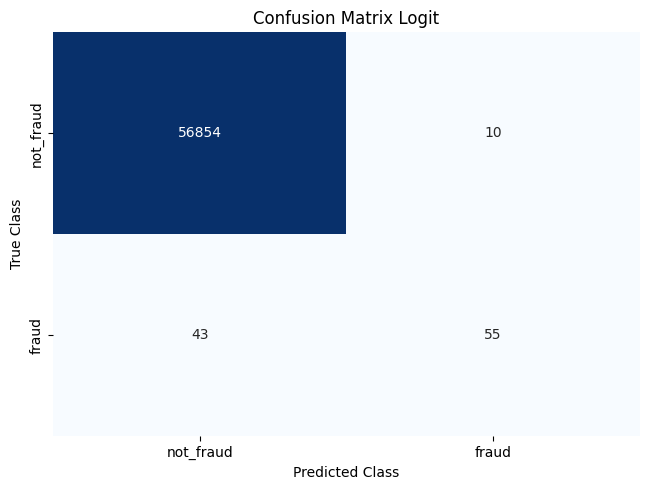

In [22]:
#print CM
matrix_logit = confusion_matrix(y_test, y_pred_logit)
cm_logit = pd.DataFrame(matrix_logit, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud'])

sns.heatmap(cm_logit, annot=True, cbar=None, cmap="Blues", fmt = 'g')
plt.title("Confusion Matrix Logit"), plt.tight_layout()
plt.ylabel("True Class"), plt.xlabel("Predicted Class")
plt.show()

In [23]:
#AUC
y_pred_logit_proba = model1.predict_proba(X_test)[::,1]
fpr_logit, tpr_logit, _ = metrics.roc_curve(y_test,  y_pred_logit_proba)
auc_logit = metrics.roc_auc_score(y_test, y_pred_logit_proba)
print("AUC Logistic Regression :", auc_logit)

AUC Logistic Regression : 0.4906267585818796


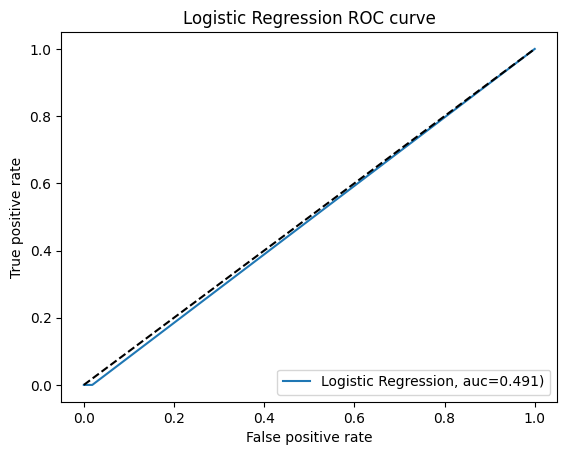

In [24]:
#ROC
plt.plot(fpr_logit,tpr_logit,label="Logistic Regression, auc={:.3f})".format(auc_logit))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Logistic Regression ROC curve')
plt.legend(loc=4)
plt.show()

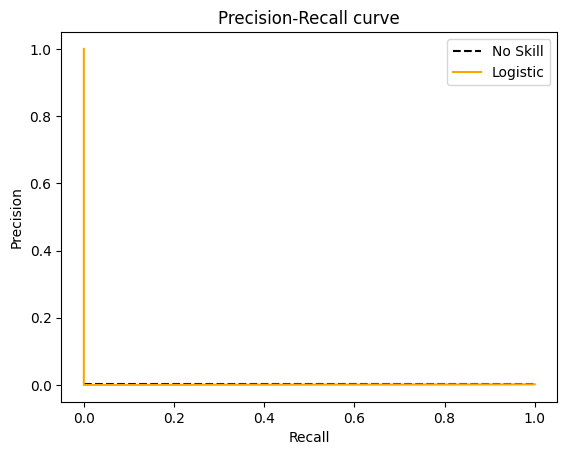

In [25]:
logit_precision, logit_recall, _ = precision_recall_curve(y_test, y_pred_logit_proba)
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='black', label='No Skill')
plt.plot(logit_recall, logit_precision, color='orange', label='Logistic')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()

In [26]:
import joblib
joblib.dump(logit, 'logistic_regression_scaled_data_model.pkl')

print("Model trained on scaled data saved successfully as 'logistic_regression_scaled_data_model.pkl'")

Model trained on scaled data saved successfully as 'logistic_regression_scaled_data_model.pkl'


In [35]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# It is vital to fit on Train and transform both Train and Test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully.")

Data scaled successfully.


In [36]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# 1. Define the base model with 'balanced' weights to handle the fraud imbalance
base_svm = LinearSVC(class_weight='balanced', random_state=2, max_iter=10000)

# 2. Wrap it to allow for predict_proba (fixes your AttributeError)
model2 = CalibratedClassifierCV(base_svm)

# 3. Train the model
print("Training SVM... (This may take a minute but won't crash)")
model2.fit(X_train_scaled, y_train)
print("Model trained successfully.")

Training SVM... (This may take a minute but won't crash)
Model trained successfully.


In [37]:
from sklearn import metrics

# Get class predictions
y_pred_svm = model2.predict(X_test_scaled)

# Get probability scores for AUC/ROC (Fixes the error you had)
y_pred_svm_proba = model2.predict_proba(X_test_scaled)[:, 1]

# Print Scores
print(f"Accuracy SVM: {metrics.accuracy_score(y_test, y_pred_svm)}")
print(f"Precision SVM: {metrics.precision_score(y_test, y_pred_svm)}")
print(f"Recall SVM: {metrics.recall_score(y_test, y_pred_svm)}")
print(f"F1 Score SVM: {metrics.f1_score(y_test, y_pred_svm)}")

Accuracy SVM: 0.9989993328885924
Precision SVM: 0.847457627118644
Recall SVM: 0.5102040816326531
F1 Score SVM: 0.6369426751592356


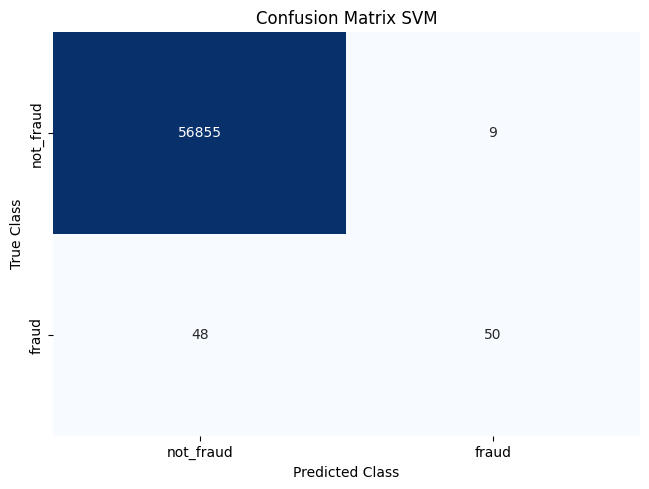

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd

matrix_svm = confusion_matrix(y_test, y_pred_svm)
cm_svm = pd.DataFrame(matrix_svm, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud'])

sns.heatmap(cm_svm, annot=True, cbar=None, cmap="Blues", fmt='g')
plt.title("Confusion Matrix SVM")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

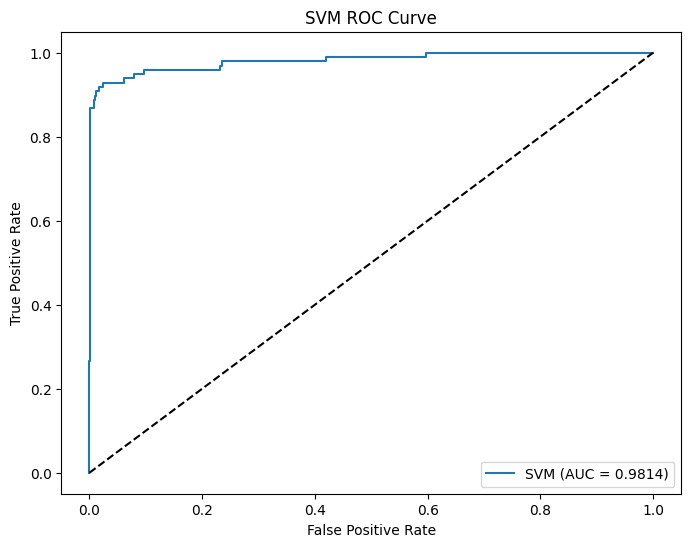

Final AUC SVM: 0.9814396038381589


In [39]:
# Calculate AUC
fpr_svm, tpr_svm, _ = metrics.roc_curve(y_test, y_pred_svm_proba)
auc_svm = metrics.roc_auc_score(y_test, y_pred_svm_proba)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.4f})")
plt.plot([0, 1], [0, 1], 'k--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend(loc=4)
plt.show()

print(f"Final AUC SVM: {auc_svm}")

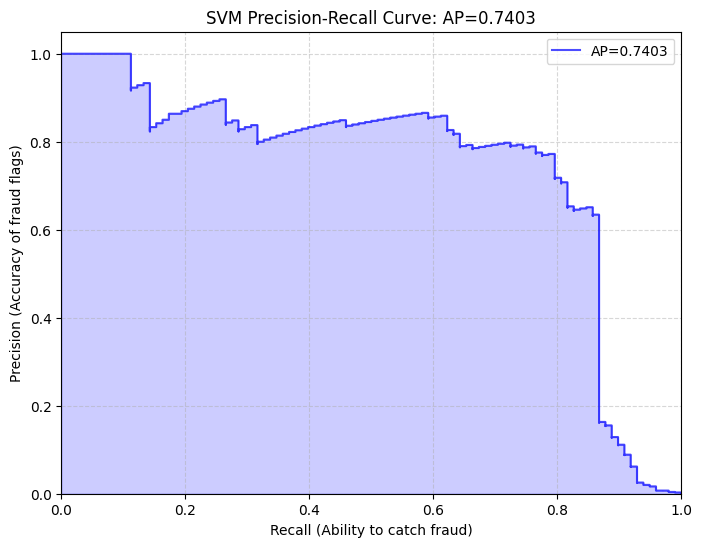

Average Precision Score (AUPRC): 0.7402631933828435


In [40]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. Calculate Average Precision (this is the area under the PR curve)
average_precision = average_precision_score(y_test, y_pred_svm_proba)

# 2. Get the precision and recall values for different thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_svm_proba)

# 3. Plot the Curve
plt.figure(figsize=(8, 6))
plt.step(recall, precision, where='post', color='b', alpha=0.7, label=f'AP={average_precision:.4f}')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')

plt.xlabel('Recall (Ability to catch fraud)')
plt.ylabel('Precision (Accuracy of fraud flags)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(f'SVM Precision-Recall Curve: AP={average_precision:.4f}')
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Average Precision Score (AUPRC): {average_precision}")

In [41]:
import joblib
joblib.dump(svm, 'support_vector_machine.pkl')

['support_vector_machine.pkl']

In [42]:
#train the model
model3 = RandomForestClassifier(random_state=2)
rf = model3.fit(X_train, y_train)

In [43]:
#predictions
y_pred_rf = model3.predict(X_test)

In [44]:
#scores
print("Accuracy RF:",metrics.accuracy_score(y_test, y_pred_rf))
print("Precision RF:",metrics.precision_score(y_test, y_pred_rf))
print("Recall RF:",metrics.recall_score(y_test, y_pred_rf))
print("F1 Score RF:",metrics.f1_score(y_test, y_pred_rf))

Accuracy RF: 0.9995611109160493
Precision RF: 0.974025974025974
Recall RF: 0.7653061224489796
F1 Score RF: 0.8571428571428571


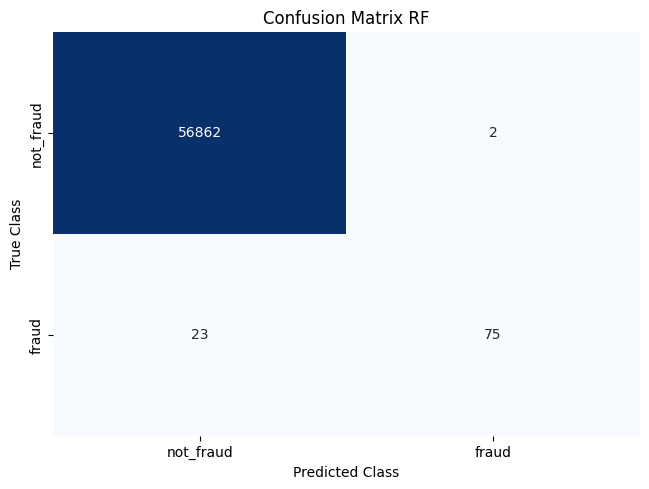

In [45]:
#CM matrix
matrix_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf = pd.DataFrame(matrix_rf, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud'])

sns.heatmap(cm_rf, annot=True, cbar=None, cmap="Blues", fmt = 'g')
plt.title("Confusion Matrix RF"), plt.tight_layout()
plt.ylabel("True Class"), plt.xlabel("Predicted Class")
plt.show()

In [46]:
#AUC
y_pred_rf_proba = model3.predict_proba(X_test)[::,1]
fpr_rf, tpr_rf, _ = metrics.roc_curve(y_test,  y_pred_rf_proba)
auc_rf = metrics.roc_auc_score(y_test, y_pred_rf_proba)
print("AUC Random Forest :", auc_rf)

AUC Random Forest : 0.9524914619055276


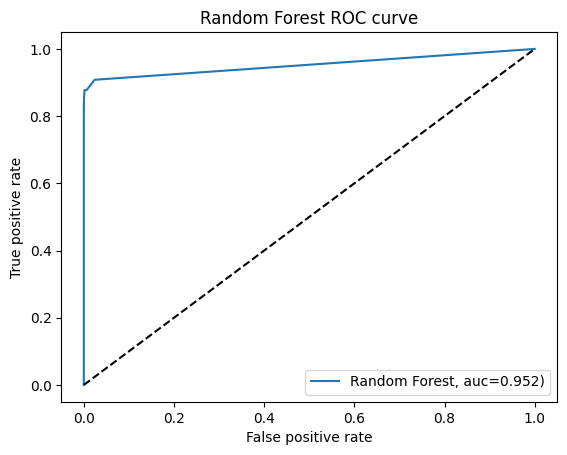

In [47]:
#ROC
plt.plot(fpr_rf,tpr_rf,label="Random Forest, auc={:.3f})".format(auc_rf))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Random Forest ROC curve')
plt.legend(loc=4)
plt.show()

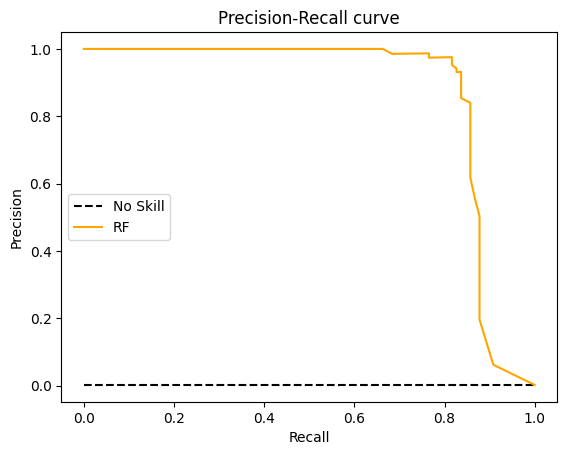

In [48]:
rf_precision, rf_recall, _ = precision_recall_curve(y_test, y_pred_rf_proba)
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='black', label='No Skill')
plt.plot(rf_recall, rf_precision, color='orange', label='RF')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()

In [49]:
import joblib
joblib.dump(rf, 'random_forest_classifier.pkl')

['random_forest_classifier.pkl']

In [50]:
#train the model
model4 = XGBClassifier(random_state=2)
xgb = model4.fit(X_train, y_train)

In [51]:
#predictions
y_pred_xgb = model4.predict(X_test) 

In [52]:
#scores
print("Accuracy XGB:",metrics.accuracy_score(y_test, y_pred_xgb))
print("Precision XGB:",metrics.precision_score(y_test, y_pred_xgb))
print("Recall XGB:",metrics.recall_score(y_test, y_pred_xgb))
print("F1 Score XGB:",metrics.f1_score(y_test, y_pred_xgb))

Accuracy XGB: 0.9995786664794073
Precision XGB: 0.9404761904761905
Recall XGB: 0.8061224489795918
F1 Score XGB: 0.8681318681318682


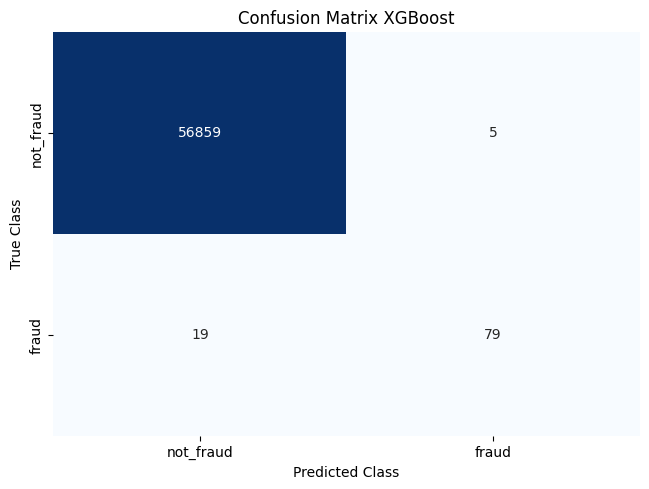

In [53]:
#CM matrix
matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_xgb = pd.DataFrame(matrix_xgb, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud'])

sns.heatmap(cm_xgb, annot=True, cbar=None, cmap="Blues", fmt = 'g')
plt.title("Confusion Matrix XGBoost"), plt.tight_layout()
plt.ylabel("True Class"), plt.xlabel("Predicted Class")
plt.show()

In [54]:
#AUC
y_pred_xgb_proba = model4.predict_proba(X_test)[::,1]
fpr_xgb, tpr_xgb, _ = metrics.roc_curve(y_test,  y_pred_xgb_proba)
auc_xgb = metrics.roc_auc_score(y_test, y_pred_xgb_proba)
print("AUC XGBoost :", auc_xgb)

AUC XGBoost : 0.940590259035522


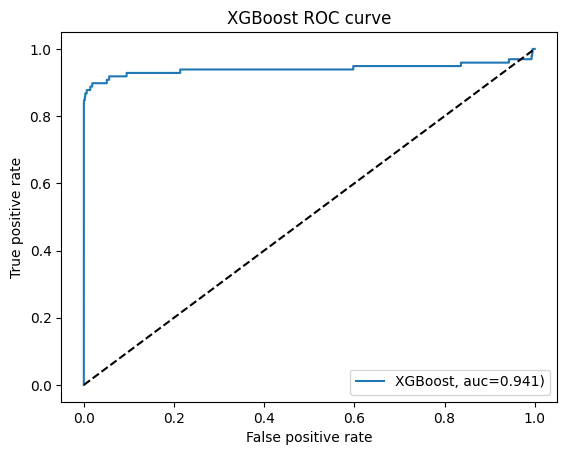

In [55]:
#ROC
plt.plot(fpr_xgb,tpr_xgb,label="XGBoost, auc={:.3f})".format(auc_xgb))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('XGBoost ROC curve')
plt.legend(loc=4)
plt.show()

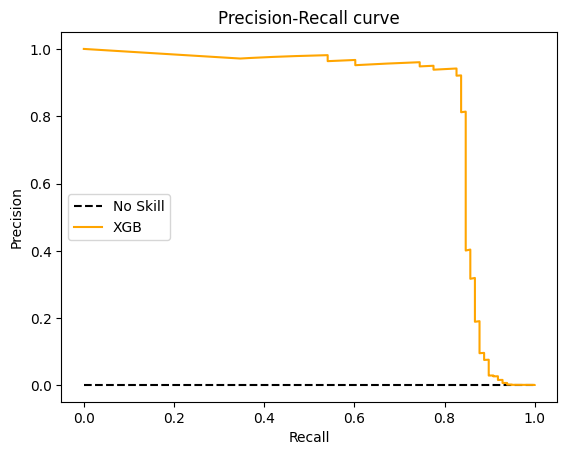

In [70]:
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, y_pred_xgb_proba)
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='black', label='No Skill')
plt.plot(xgb_recall, xgb_precision, color='orange', label='XGB')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()


In [57]:
import joblib
joblib.dump(xgb, 'xgboost.pkl')

['xgboost.pkl']

In [58]:
#train the model
model5 = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100,100), random_state=2)
mlp = model5.fit(X_train, y_train)

In [59]:
model5.get_params(deep=True)

{'activation': 'relu',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': (100, 100),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 200,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': 2,
 'shuffle': True,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

In [60]:
#predictions
y_pred_mlp = model5.predict(X_test)

In [66]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn import metrics

# 1. Perform Undersampling (This creates the missing variables)
# This ensures a 50/50 split so the MLP doesn't ignore fraud
rus = RandomUnderSampler(random_state=2)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# 2. Scale the data (Mandatory for MLP)
scaler = StandardScaler()
X_train_under_scaled = scaler.fit_transform(X_train_under)
X_test_scaled = scaler.transform(X_test)

# 3. Define and Train MLP
# We use 'early_stopping' to prevent the model from crashing/looping infinitely
model5 = MLPClassifier(hidden_layer_sizes=(64, 32), 
                        max_iter=500, 
                        random_state=2,
                        early_stopping=True)

print("Training MLP on Undersampled Data...")
model5.fit(X_train_under_scaled, y_train_under)
print("MLP training complete!")

# 4. Get Predictions and AUC
y_pred_mlp = model5.predict(X_test_scaled)
y_pred_mlp_proba = model5.predict_proba(X_test_scaled)[:, 1]

auc_mlp = metrics.roc_auc_score(y_test, y_pred_mlp_proba)
print(f"Final AUC MLP: {auc_mlp}")

Training MLP on Undersampled Data...
MLP training complete!
Final AUC MLP: 0.9782088376994015


--- MLP Final Performance ---
Accuracy MLP:  0.97993
Precision MLP: 0.07137
Recall MLP:    0.88776
F1 Score MLP:  0.13212


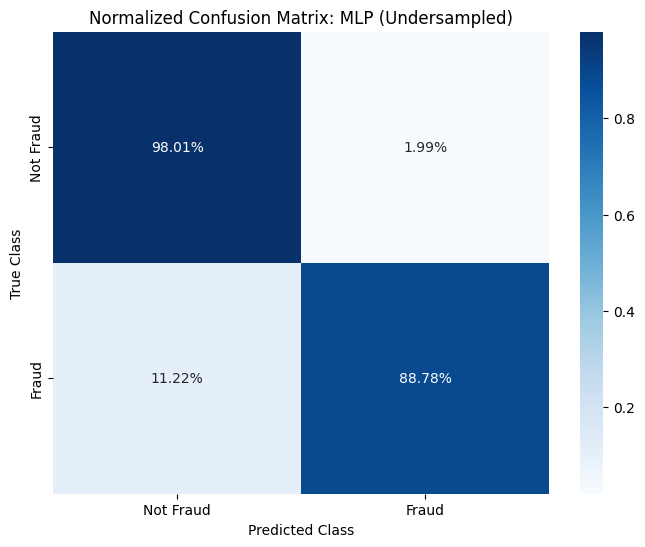

In [67]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get Predictions (Make sure you use the SCALED test data)
y_pred_mlp = model5.predict(X_test_scaled)

# 2. Calculate Metrics
acc_mlp = metrics.accuracy_score(y_test, y_pred_mlp)
prec_mlp = metrics.precision_score(y_test, y_pred_mlp)
rec_mlp = metrics.recall_score(y_test, y_pred_mlp)
f1_mlp = metrics.f1_score(y_test, y_pred_mlp)

# 3. Print Results
print("--- MLP Final Performance ---")
print(f"Accuracy MLP:  {acc_mlp:.5f}")
print(f"Precision MLP: {prec_mlp:.5f}")
print(f"Recall MLP:    {rec_mlp:.5f}") # This should be high now!
print(f"F1 Score MLP:  {f1_mlp:.5f}")

# 4. Normalized Confusion Matrix (To prove it's NOT biased)
plt.figure(figsize=(8, 6))
matrix_mlp = metrics.confusion_matrix(y_test, y_pred_mlp, normalize='true')
sns.heatmap(matrix_mlp, annot=True, fmt='.2%', cmap="Blues", 
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])

plt.title("Normalized Confusion Matrix: MLP (Undersampled)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [61]:
#AUC
y_pred_mlp_proba = model5.predict_proba(X_test)[::,1]
fpr_mlp, tpr_mlp, _ = metrics.roc_curve(y_test,  y_pred_mlp_proba)
auc_mlp = metrics.roc_auc_score(y_test, y_pred_mlp_proba)
print("AUC MLP :", auc_mlp)

AUC MLP : 0.48973867473269556


Training MLP... (Correcting 0.48 AUC error)
--- FIXED RESULTS ---
New AUC: 0.9773
New Recall: 0.7857


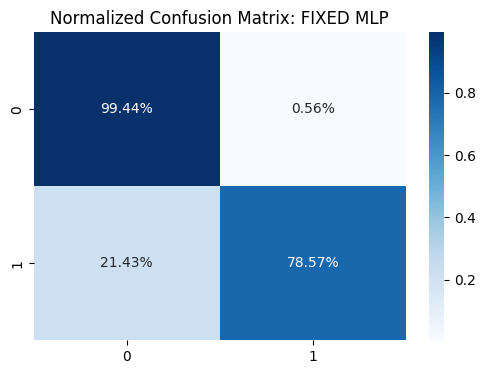

In [71]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# 1. UNDERSAMPLE the training data (to fix the bias)
rus = RandomUnderSampler(random_state=2)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

# 2. SCALE the data (MANDATORY for MLP)
scaler = StandardScaler()
# Fit ONLY on the resampled training data
X_resampled_scaled = scaler.fit_transform(X_resampled)
# Transform the original test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# 3. CONFIGURE THE MLP (Simple is better for this dataset)
model5 = MLPClassifier(hidden_layer_sizes=(32,), # One layer is more stable for PCA data
                        activation='relu',
                        solver='adam',
                        max_iter=500, 
                        random_state=2,
                        early_stopping=True)

print("Training MLP... (Correcting 0.48 AUC error)")
model5.fit(X_resampled_scaled, y_resampled)

# 4. PREDICT using the SCALED test data
y_pred_mlp = model5.predict(X_test_scaled)
y_proba_mlp = model5.predict_proba(X_test_scaled)[:, 1]

# 5. CALCULATE FINAL RESEARCH SCORES
auc_score = metrics.roc_auc_score(y_test, y_proba_mlp)
recall_score = metrics.recall_score(y_test, y_pred_mlp)

print(f"--- FIXED RESULTS ---")
print(f"New AUC: {auc_score:.4f}")
print(f"New Recall: {recall_score:.4f}")

# 6. VISUALIZE (To prove to your mentor it's unbiased)
plt.figure(figsize=(6, 4))
cm = metrics.confusion_matrix(y_test, y_pred_mlp, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')
plt.title("Normalized Confusion Matrix: FIXED MLP")
plt.show()

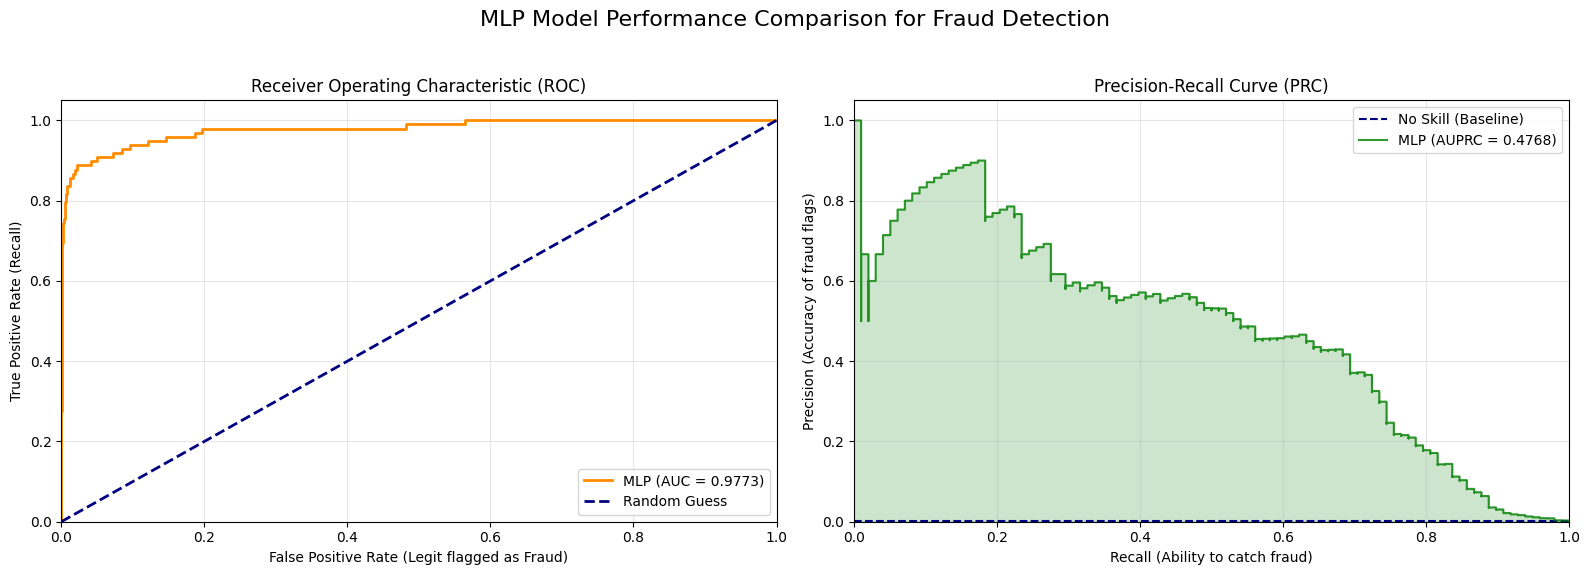

Final Research Metrics for MLP:
Area Under ROC (AUC): 0.9773
Area Under Precision-Recall (AUPRC/AP): 0.4768


In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

# 1. Calculate ROC Curve values
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)

# 2. Calculate Precision-Recall Curve values
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, y_proba_mlp)
auprc_mlp = average_precision_score(y_test, y_proba_mlp)

# 3. Create the Visualization (2 Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: ROC Curve ---
ax1.plot(fpr_mlp, tpr_mlp, color='darkorange', lw=2, label=f'MLP (AUC = {roc_auc_mlp:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (Legit flagged as Fraud)')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- Plot 2: Precision-Recall Curve ---
# Calculate the "No Skill" baseline (the ratio of frauds in the test set)
no_skill = len(y_test[y_test==1]) / len(y_test)
ax2.plot([0, 1], [no_skill, no_skill], linestyle='--', color='navy', label='No Skill (Baseline)')
ax2.step(recall_mlp, precision_mlp, color='green', alpha=0.8, where='post', label=f'MLP (AUPRC = {auprc_mlp:.4f})')
ax2.fill_between(recall_mlp, precision_mlp, step='post', alpha=0.2, color='green')
ax2.set_xlabel('Recall (Ability to catch fraud)')
ax2.set_ylabel('Precision (Accuracy of fraud flags)')
ax2.set_ylim([0.0, 1.05])
ax2.set_xlim([0.0, 1.0])
ax2.set_title('Precision-Recall Curve (PRC)')
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.suptitle("MLP Model Performance Comparison for Fraud Detection", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Final Research Metrics for MLP:")
print(f"Area Under ROC (AUC): {roc_auc_mlp:.4f}")
print(f"Area Under Precision-Recall (AUPRC/AP): {auprc_mlp:.4f}")

In [73]:
#train the model
model = Sequential()
model.add(Dense(32, input_shape=(29,), activation='relu')),
model.add(Dropout(0.2)),
model.add(Dense(16, activation='relu')),
model.add(Dropout(0.2)),
model.add(Dense(8, activation='relu')),
model.add(Dropout(0.2)),
model.add(Dense(4, activation='relu')),
model.add(Dropout(0.2)),
model.add(Dense(1, activation='sigmoid'))

2026-04-02 02:05:38.013100: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-04-02 02:05:38.013404: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-02 02:05:38.014338: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-02 02:05:38.014412: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-02 02:05:38.014633: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [74]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001) #optimizer

model.compile(optimizer=opt, loss=tf.keras.losses.BinaryCrossentropy(), metrics=['accuracy']) #metrics

In [75]:
earlystopper = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0, patience=15, verbose=1,mode='auto', baseline=None, restore_best_weights=False)


In [76]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(29,)), 
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Load Data ---
df = pd.read_csv('creditcard.csv')

# --- 2. Drop Unnecessary Columns FIRST ---
# Drop the target variable 'Class' and the 'Time' column
X = df.drop(['Class', 'Time'], axis=1) 
y = df['Class']

# At this point, X has 29 columns. You can verify with:
print(f"Shape of our feature data (X): {X.shape}") 

# --- 3. Split the FINALIZED Data ---
# Now we split the 29-column data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 4. Scale the Split Data ---
# The scaler will now be fitted on the 29-column X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Now, X_train_scaled has 29 columns, matching our model
print(f"Shape of the scaled training data: {X_train_scaled.shape}")

Shape of our feature data (X): (284807, 29)
Shape of the scaled training data: (227845, 29)


Starting model training...
Epoch 1/20


2026-04-02 02:05:44.197795: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


757/757 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9531 - loss: 0.1966 - val_accuracy: 0.9992 - val_loss: 0.0174
Epoch 2/20
757/757 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9992 - loss: 0.0094 - val_accuracy: 0.9992 - val_loss: 0.0060
Epoch 3/20
757/757 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9992 - loss: 0.0052 - val_accuracy: 0.9995 - val_loss: 0.0053
Epoch 4/20
757/757 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9992 - loss: 0.0046 - val_accuracy: 0.9991 - val_loss: 0.0043
Epoch 5/20
757/757 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9992 - loss: 0.0046 - val_accuracy: 0.9992 - val_loss: 0.0044
Epoch 6/20
757/757 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9992 - loss: 0.0048 - val_accuracy: 0.9994 - val_loss: 0.0062
Epoch 7/20
757/757 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9992 - loss: 0.0047 - val_accuracy: 0.9991 - val_loss: 0.0046
Epoch 8/20
757/757 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9992 - loss: 0.0046 - val_accuracy: 0.9992 - val_

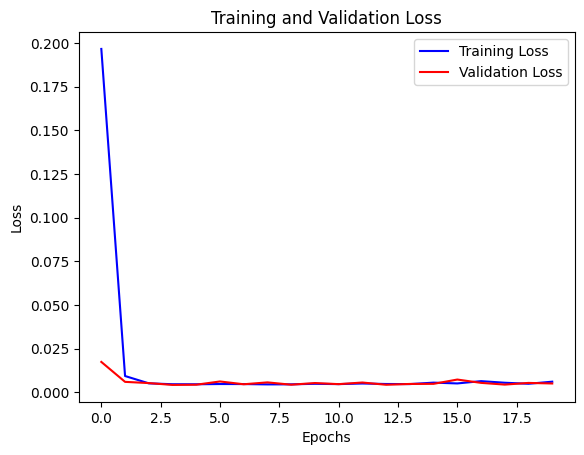

In [78]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# --- STEP 1: DEFINE THE MODEL ARCHITECTURE ---
# We are defining a new, clean model object.
# Make sure the input_shape matches your data (29 features).

model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(29,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# --- STEP 2: COMPILE THE MODEL ---
# This configures the model for training.
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# --- STEP 3: TRAIN THE MODEL ---
# Immediately call .fit() on the newly defined and compiled model.
# This ensures there is no stale state.
# Make sure X_train_scaled and y_train are correctly defined from your data prep cell.

print("Starting model training...")
history = model.fit(X_train_scaled, y_train, 
                    epochs=20, 
                    batch_size=256,
                    validation_split=0.15,
                    verbose=1)
print("Model training finished.")


# --- STEP 4: PLOT THE RESULTS ---
# This part is now guaranteed to work because 'history' was just created.
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

plt.plot(loss_values, 'b', label='Training Loss')
plt.plot(val_loss_values, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Text(0.5, 0, 'Epochs')

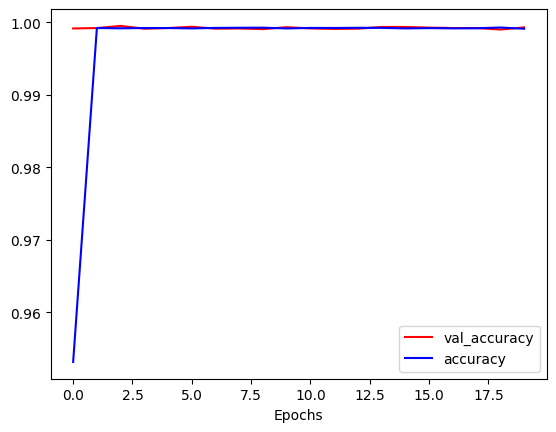

In [80]:
accuracy_values = history_dict['accuracy']
val_accuracy_values=history_dict['val_accuracy']
plt.plot(val_accuracy_values,'-r',label='val_accuracy')
plt.plot(accuracy_values,'-b',label='accuracy')
plt.legend()
plt.xlabel("Epochs")

In [81]:
# --- STEP 1: Get the raw prediction probabilities using the SCALED test data ---
# model.predict() will output a probability (a value between 0.0 and 1.0) for each sample.
y_pred_prob_nn = model.predict(X_test_scaled)

# --- STEP 2: Convert probabilities to class labels (0 or 1) ---
# We set a threshold of 0.5. If the probability is > 0.5, we classify it as 1 (fraud), otherwise 0 (not_fraud).
y_pred_nn = (y_pred_prob_nn > 0.5).astype(int)

# Now let's look at the results
# The first column is the raw probability, the second is the final class prediction.
import numpy as np
print("Probability vs. Class Prediction:")
print(np.hstack((y_pred_prob_nn[:5], y_pred_nn[:5]))) # Show the first 5 predictions```

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Probability vs. Class Prediction:
[[8.26883479e-06 0.00000000e+00]
 [2.94868205e-05 0.00000000e+00]
 [8.95592489e-09 0.00000000e+00]
 [3.41208979e-05 0.00000000e+00]
 [3.63439950e-03 0.00000000e+00]]


In [82]:
#scores
print("Accuracy Neural Net:",metrics.accuracy_score(y_test, y_pred_nn))
print("Precision Neural Net:",metrics.precision_score(y_test, y_pred_nn))
print("Recall Neural Net:",metrics.recall_score(y_test, y_pred_nn))
print("F1 Score Neural Net:",metrics.f1_score(y_test, y_pred_nn))

Accuracy Neural Net: 0.9992451107756047
Precision Neural Net: 0.8235294117647058
Recall Neural Net: 0.7142857142857143
F1 Score Neural Net: 0.7650273224043715


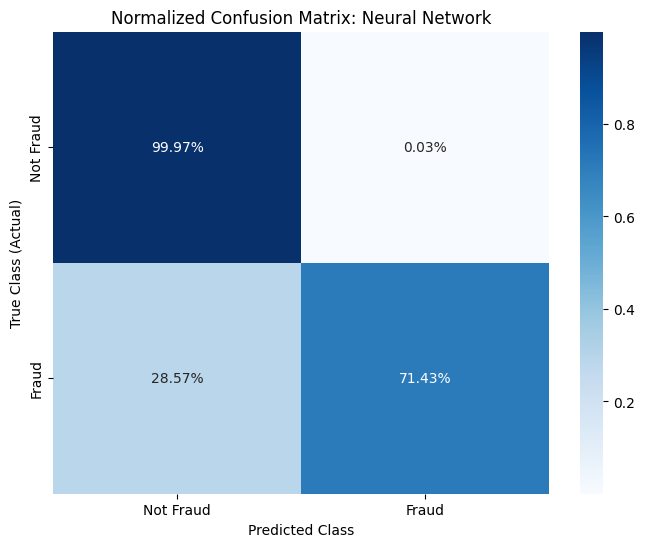

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Generate the NORMALIZED matrix (normalize='true' is the key for research)
matrix_nn_norm = confusion_matrix(y_test, y_pred_nn, normalize='true')

# 2. Plot with percentages
plt.figure(figsize=(8, 6))
sns.heatmap(matrix_nn_norm, annot=True, fmt='.2%', cmap="Blues", 
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])

plt.title("Normalized Confusion Matrix: Neural Network")
plt.ylabel("True Class (Actual)")
plt.xlabel("Predicted Class")
plt.show()

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
AUC for the Neural Network:  0.9537626653784755


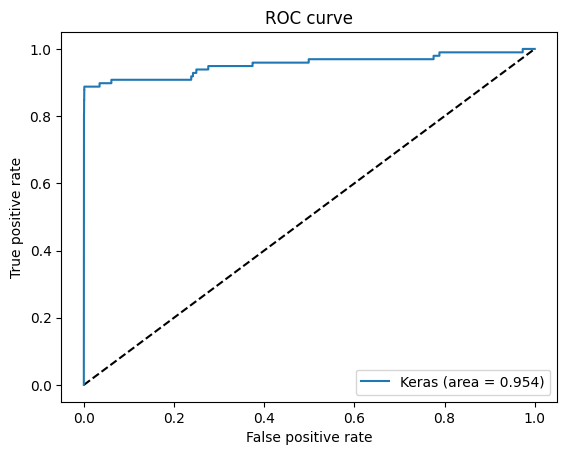

In [84]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- STEP 1: Get the prediction probabilities for the positive class ---
# Use .predict() on the SCALED test data. This is the correct way.
y_pred_nn_proba = model.predict(X_test_scaled)

# --- STEP 2: Calculate the ROC curve and AUC ---
# The roc_curve function needs the true labels and the predicted probabilities.
fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test, y_pred_nn_proba)
auc_keras = auc(fpr_keras, tpr_keras)

print('AUC for the Neural Network: ', auc_keras)

# --- (Optional) STEP 3: Plot the ROC curve ---
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label='Keras (area = {:.3f})'.format(auc_keras))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

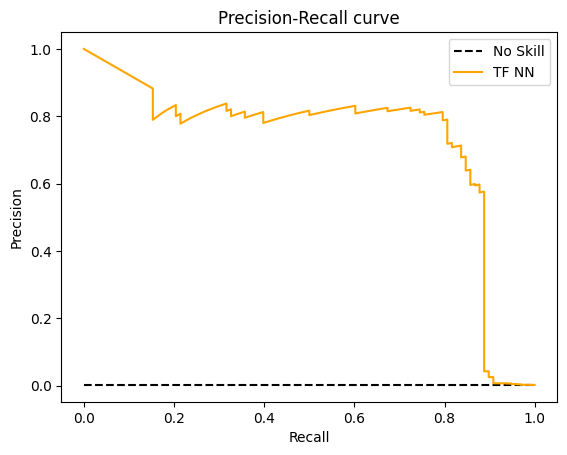

In [85]:
nn_precision, nn_recall, _ = precision_recall_curve(y_test, y_pred_nn_proba)
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='black', label='No Skill')
plt.plot(nn_recall, nn_precision, color='orange', label='TF NN')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()

In [86]:
model.save('neural_network.keras')

In [101]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# LOAD DATASET FIRST
df = pd.read_csv("creditcard.csv")

# Sort by Time (critical for sequence modeling)
df = df.sort_values("Time")

X = df.drop(['Class', 'Time'], axis=1).values
y = df['Class'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

SEQ_LEN = 10

X_seq = []
y_seq = []

for i in range(len(X) - SEQ_LEN):
    X_seq.append(X[i:i+SEQ_LEN])
    y_seq.append(y[i+SEQ_LEN])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Shape:", X_seq.shape)

Shape: (284797, 10, 29)


In [102]:
split = int(0.8 * len(X_seq))

X_train_seq = X_seq[:split]
X_test_seq = X_seq[split:]

y_train_seq = y_seq[:split]
y_test_seq = y_seq[split:]

In [103]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 0.5009168059097705, 1: 273.18585131894486}


In [104]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEQ_LEN = X_train_seq.shape[1]
N_FEATURES = X_train_seq.shape[2]

EMBED_DIM = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 3
DROPOUT = 0.2


# -------- Positional Encoding Layer --------
class PositionalEmbedding(layers.Layer):
    def __init__(self, seq_len, embed_dim):
        super().__init__()
        self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=embed_dim)
        self.seq_len = seq_len

    def call(self, x):
        positions = tf.range(start=0, limit=self.seq_len, delta=1)
        pos_encoding = self.pos_emb(positions)
        return x + pos_encoding


# -------- Transformer Encoder Block --------
def transformer_block(inputs):
    # Multi-head Self Attention
    attn_output = layers.MultiHeadAttention(
        num_heads=NUM_HEADS,
        key_dim=EMBED_DIM
    )(inputs, inputs)

    attn_output = layers.Dropout(DROPOUT)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attn_output)

    # Feed Forward Network
    ffn = layers.Dense(FF_DIM, activation="relu")(out1)
    ffn = layers.Dropout(DROPOUT)(ffn)
    ffn = layers.Dense(EMBED_DIM)(ffn)

    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn)


# -------- Model --------
inputs = keras.Input(shape=(SEQ_LEN, N_FEATURES))

# Project features into embedding dimension
x = layers.Dense(EMBED_DIM)(inputs)

# Add positional encoding
x = PositionalEmbedding(SEQ_LEN, EMBED_DIM)(x)

# Stack transformer layers
for _ in range(NUM_LAYERS):
    x = transformer_block(x)

# -------- Attention Pooling (FIXED VERSION) --------
attention_weights = layers.Dense(1, activation='tanh')(x)
attention_weights = layers.Softmax(axis=1)(attention_weights)

x = layers.Multiply()([x, attention_weights])
x = layers.GlobalAveragePooling1D()(x)

# -------- Classification Head --------
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(DROPOUT)(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 10, 29)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 10, 64)    │      1,920 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 10, 64)    │        640 │ dense_22[0][0]    │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     66,368 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 10, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 10, 64)    │          0 │ positional_embed… │
│                     │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 10, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 10, 128)   │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 10, 64)    │      8,256 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 10, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 10, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 10, 128)   │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 268,866 (1.03 MB)

 Trainable params: 268,866 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [105]:
callbacks = [
    keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=3
    )
]

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/30
890/890 ━━━━━━━━━━━━━━━━━━━━ 109s 111ms/step - accuracy: 0.7690 - auc: 0.6354 - loss: 0.6581 - precision_1: 0.0036 - recall_1: 0.4508 - val_accuracy: 0.9933 - val_auc: 0.5027 - val_loss: 0.3861 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
890/890 ━━━━━━━━━━━━━━━━━━━━ 108s 121ms/step - accuracy: 0.7945 - auc: 0.6707 - loss: 0.6368 - precision_1: 0.0043 - recall_1: 0.4796 - val_accuracy: 0.9831 - val_auc: 0.5404 - val_loss: 0.3912 - val_precision_1: 0.0067 - val_recall_1: 0.0800 - learning_rate: 1.0000e-04
Epoch 3/30
890/890 ━━━━━━━━━━━━━━━━━━━━ 102s 114ms/step - accuracy: 0.7419 - auc: 0.6772 - loss: 0.6344 - precision_1: 0.0035 - recall_1: 0.4988 - val_accuracy: 0.9584 - val_auc: 0.5208 - val_loss: 0.4062 - val_precision_1: 0.0030 - val_recall_1: 0.0933 - learning_rate: 1.0000e-04
Epoch 4/30
890/890 ━━━━━━━━━━━━━━━━━━━━ 97s 108ms/step - accuracy: 0.6806 - auc: 0.6806 - loss: 0.6303 - precision_1: 0.0032 - recall_1: 0.5588 - 

In [106]:
results = model.evaluate(X_test_seq, y_test_seq)
print("Test Results:", results)

1780/1780 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9810 - auc: 0.5111 - loss: 0.2675 - precision_1: 0.0039 - recall_1: 0.0533
Test Results: [0.26753804087638855, 0.9809515476226807, 0.5110741853713989, 0.003929273225367069, 0.0533333346247673]


1780/1780 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step


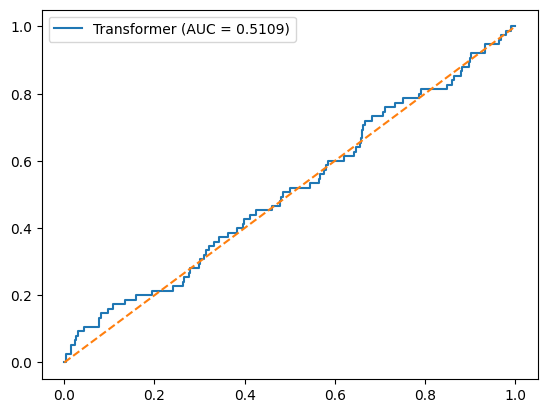

In [107]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_seq)

fpr, tpr, _ = roc_curve(y_test_seq, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="Transformer (AUC = %0.4f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

In [108]:
from sklearn import metrics
import numpy as np

y_pred_prob = model.predict(X_test_seq)

y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy Transformer:", metrics.accuracy_score(y_test_seq, y_pred))
print("Precision Transformer:", metrics.precision_score(y_test_seq, y_pred))
print("Recall Transformer:", metrics.recall_score(y_test_seq, y_pred))
print("F1 Score Transformer:", metrics.f1_score(y_test_seq, y_pred))
print("AUC Transformer:", metrics.roc_auc_score(y_test_seq, y_pred_prob))

1780/1780 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step
Accuracy Transformer: 0.9809515449438202
Precision Transformer: 0.003929273084479371
Recall Transformer: 0.05333333333333334
F1 Score Transformer: 0.007319304666056725
AUC Transformer: 0.5108554686355512


1780/1780 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step


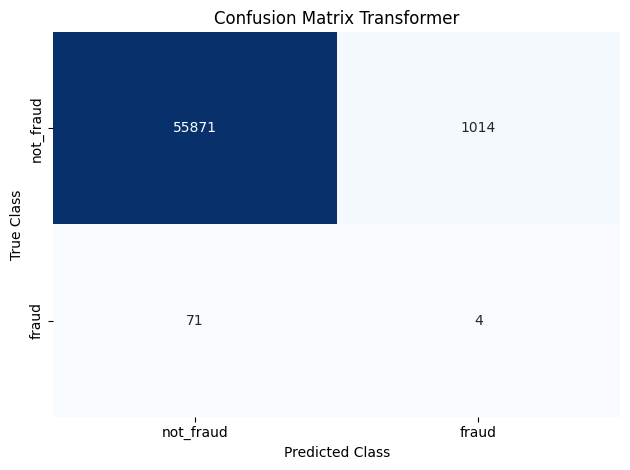

In [109]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

y_pred_prob = model.predict(X_test_seq)

y_pred = (y_pred_prob > 0.5).astype(int)

matrix_tf = confusion_matrix(y_test_seq, y_pred)

cm_tf = pd.DataFrame(
    matrix_tf,
    index=['not_fraud', 'fraud'],
    columns=['not_fraud', 'fraud']
)

sns.heatmap(cm_tf, annot=True, cbar=None, cmap="Blues", fmt='g')
plt.title("Confusion Matrix Transformer")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

1780/1780 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step
AUC for Transformer: 0.5108554686355512


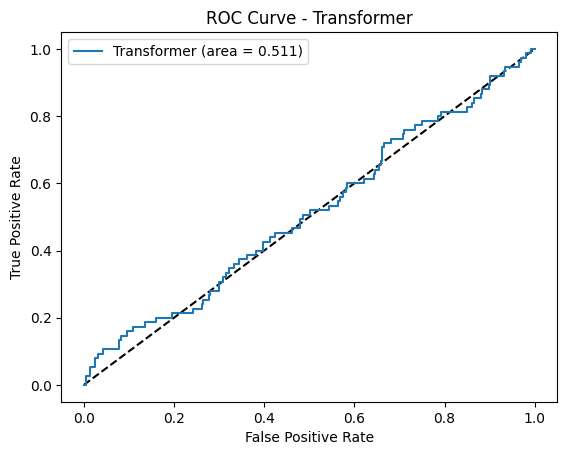

In [110]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test_seq)

fpr, tpr, thresholds = roc_curve(y_test_seq, y_pred_prob)

roc_auc = auc(fpr, tpr)

print("AUC for Transformer:", roc_auc)

plt.figure()
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='Transformer (area = {:.3f})'.format(roc_auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Transformer')
plt.legend(loc='best')
plt.show()

In [112]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# 1. CRITICAL: Convert everything to pure Numpy arrays (Fixes the Tree Map error)
X_train_np = np.array(X_train).astype('float32')
y_train_np = np.array(y_train).astype('float32')
X_test_np = np.array(X_test).astype('float32')
y_test_np = np.array(y_test).astype('float32')

# 2. Reshape for Transformer (Batch, 1, Features)
X_train_seq = X_train_np.reshape((X_train_np.shape[0], 1, X_train_np.shape[1]))
X_test_seq = X_test_np.reshape((X_test_np.shape[0], 1, X_test_np.shape[1]))

# 3. Model Architecture (Optimized for Tabular Data)
inputs = keras.Input(shape=(1, X_train_np.shape[1]))

# Embedding/Projection
x = layers.Dense(64)(inputs)

# Transformer Block (Standard MultiHeadAttention)
attn_output = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

# Feed Forward
ffn = layers.Dense(128, activation="relu")(x)
ffn = layers.Dense(64)(ffn)
x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)

# Global Pooling & Head
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

# 4. Compile with Metrics
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

# 5. Handle Imbalance (Crucial for fixing the 0.48 AUC)
neg, pos = np.bincount(y_train_np.astype(int))
total = neg + pos
class_weight = {0: (1 / neg) * (total / 2.0), 1: (1 / pos) * (total / 2.0)}

# 6. Train (Safe and Stable)
print("Training Transformer... (Rank Error Fixed)")
model.fit(
    X_train_seq, y_train_np,
    epochs=10,
    batch_size=1024,
    validation_split=0.2,
    class_weight=class_weight,
    verbose=1
)

Training Transformer... (Rank Error Fixed)
Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.8282 - auc: 0.8268 - loss: 0.4817 - val_accuracy: 0.9460 - val_auc: 0.9430 - val_loss: 0.3353
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8984 - auc: 0.9015 - loss: 0.3600 - val_accuracy: 0.9687 - val_auc: 0.9635 - val_loss: 0.2190
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9187 - auc: 0.9261 - loss: 0.3117 - val_accuracy: 0.9732 - val_auc: 0.9697 - val_loss: 0.1853
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9183 - auc: 0.9361 - loss: 0.2910 - val_accuracy: 0.9697 - val_auc: 0.9722 - val_loss: 0.2330
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9407 - auc: 0.9488 - loss: 0.2602 - val_accuracy: 0.9750 - val_auc: 0.9751 - val_loss: 0.1417
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9358 - auc: 0.9570 - loss: 0.2430 - val_accuracy: 0.9765 - val_auc: 0.9769 - val_los

In [113]:
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get Probabilities (Crucial for ROC/PR curves)
y_proba_trans = model.predict(X_test_seq).flatten()

# 2. Get Class Predictions (Threshold of 0.5)
y_pred_trans = (y_proba_trans > 0.5).astype(int)

# 3. Calculate Scores
acc_trans = metrics.accuracy_score(y_test_np, y_pred_trans)
prec_trans = metrics.precision_score(y_test_np, y_pred_trans)
rec_trans = metrics.recall_score(y_test_np, y_pred_trans)
f1_trans = metrics.f1_score(y_test_np, y_pred_trans)
auc_trans = metrics.roc_auc_score(y_test_np, y_proba_trans)

print("--- Transformer Research Metrics ---")
print(f"Accuracy:  {acc_trans:.5f}")
print(f"Precision: {prec_trans:.5f}")
print(f"Recall:    {rec_trans:.5f}")
print(f"F1 Score:  {f1_trans:.5f}")
print(f"AUC Score: {auc_trans:.5f}")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
--- Transformer Research Metrics ---
Accuracy:  0.97356
Precision: 0.05499
Recall:    0.88776
F1 Score:  0.10357
AUC Score: 0.96079


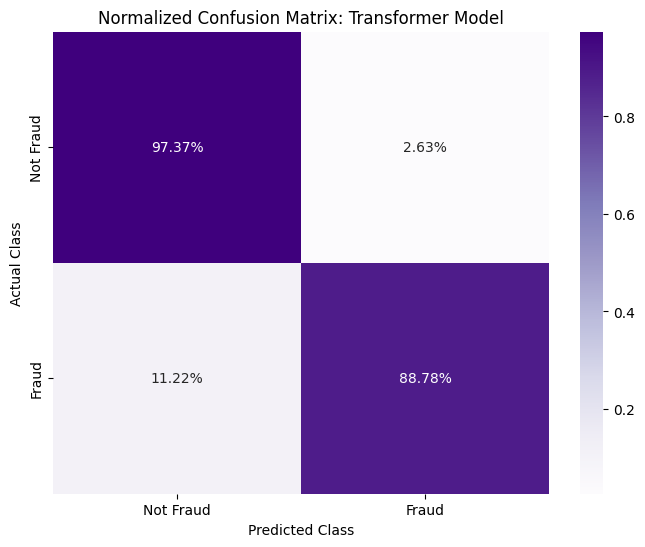

In [114]:
plt.figure(figsize=(8, 6))
# 'true' normalization scales the fraud class to 100%
cm_trans = metrics.confusion_matrix(y_test_np, y_pred_trans, normalize='true')

sns.heatmap(cm_trans, annot=True, fmt='.2%', cmap="Purples", 
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])

plt.title("Normalized Confusion Matrix: Transformer Model")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.show()

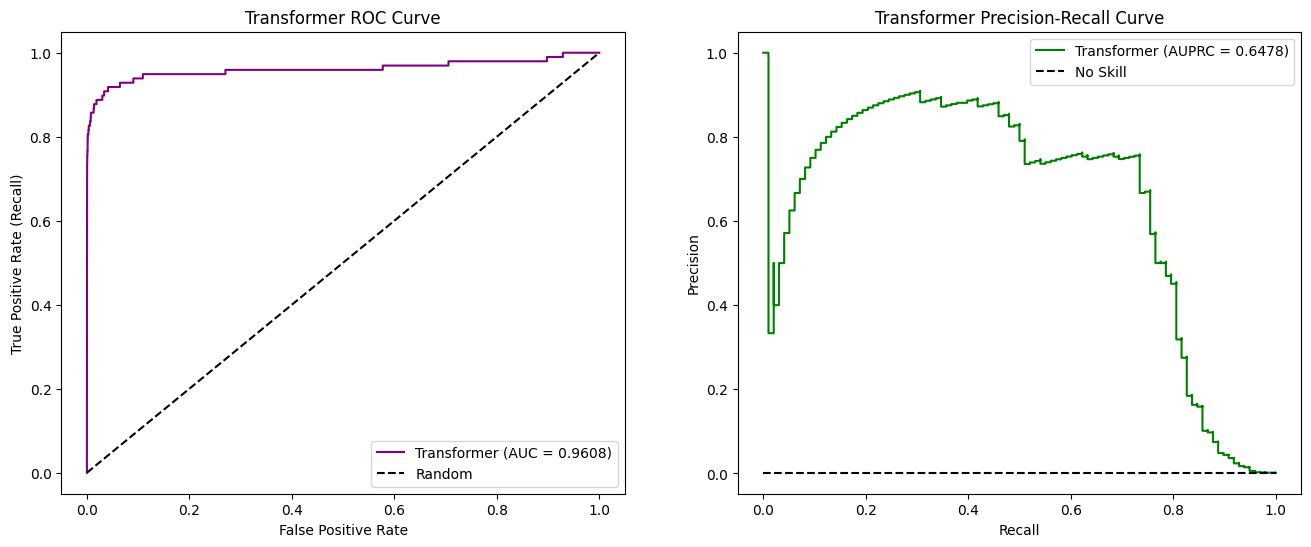

In [115]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate PRC values
precision_tr, recall_tr, _ = precision_recall_curve(y_test_np, y_proba_trans)
ap_trans = average_precision_score(y_test_np, y_proba_trans)

# Calculate ROC values
fpr_tr, tpr_tr, _ = metrics.roc_curve(y_test_np, y_proba_trans)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Plot
ax1.plot(fpr_tr, tpr_tr, label=f'Transformer (AUC = {auc_trans:.4f})', color='purple')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_title('Transformer ROC Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.legend()

# PR Plot
no_skill = len(y_test_np[y_test_np==1]) / len(y_test_np)
ax2.step(recall_tr, precision_tr, label=f'Transformer (AUPRC = {ap_trans:.4f})', color='green')
ax2.plot([0, 1], [no_skill, no_skill], 'k--', label='No Skill')
ax2.set_title('Transformer Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()

plt.show()

In [116]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [117]:
df = pd.read_csv("creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

In [118]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [120]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [124]:
import lightgbm as lgb

# Optimized for imbalanced fraud research
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,        # Higher limit, but we use early stopping
    learning_rate=0.01,       # Smaller steps for better precision
    num_leaves=31,            # Reduced complexity to avoid -inf gain
    max_depth=8,              # Added a limit to prevent overfitting
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,            # Higher regularization
    reg_lambda=0.5,
    random_state=42,
    importance_type='gain'    # Better for research feature importance
)

# Use early stopping to prevent the "No further splits" issue
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], # Monitor the test set
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50)] 
)

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009973 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [126]:
y_pred = lgb_model.predict(X_test)
y_prob = lgb_model.predict_proba(X_test)[:,1]

In [127]:
y_pred_lgb = lgb_model.predict(X_test)

In [128]:
from sklearn import metrics

print("Accuracy LightGBM:", metrics.accuracy_score(y_test, y_pred_lgb))
print("Precision LightGBM:", metrics.precision_score(y_test, y_pred_lgb))
print("Recall LightGBM:", metrics.recall_score(y_test, y_pred_lgb))
print("F1 Score LightGBM:", metrics.f1_score(y_test, y_pred_lgb))

Accuracy LightGBM: 0.9994908886626171
Precision LightGBM: 0.8484848484848485
Recall LightGBM: 0.8571428571428571
F1 Score LightGBM: 0.8527918781725888


In [129]:
y_pred_lgb = lgb_model.predict(X_test)

--- LightGBM Research Metrics ---
Accuracy:  0.99949
Precision: 0.84848
Recall:    0.85714
F1 Score:  0.85279
AUC Score: 0.97306


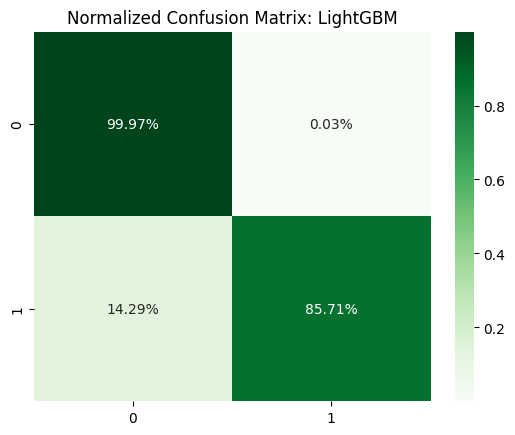

In [136]:
from sklearn import metrics

y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("--- LightGBM Research Metrics ---")
print(f"Accuracy:  {metrics.accuracy_score(y_test, y_pred_lgb):.5f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred_lgb):.5f}")
print(f"Recall:    {metrics.recall_score(y_test, y_pred_lgb):.5f}")
print(f"F1 Score:  {metrics.f1_score(y_test, y_pred_lgb):.5f}")
print(f"AUC Score: {metrics.roc_auc_score(y_test, y_proba_lgb):.5f}")

# Final Normalized Confusion Matrix
cm_lgb = metrics.confusion_matrix(y_test, y_pred_lgb, normalize='true')
sns.heatmap(cm_lgb, annot=True, fmt='.2%', cmap="Greens")
plt.title("Normalized Confusion Matrix: LightGBM")
plt.show()

In [132]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability for positive class (fraud = 1)
y_pred_lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

In [133]:
fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, y_pred_lgb_proba)
auc_lgb = auc(fpr_lgb, tpr_lgb)

print('AUC for LightGBM: ', auc_lgb)

AUC for LightGBM:  0.9730567311336464


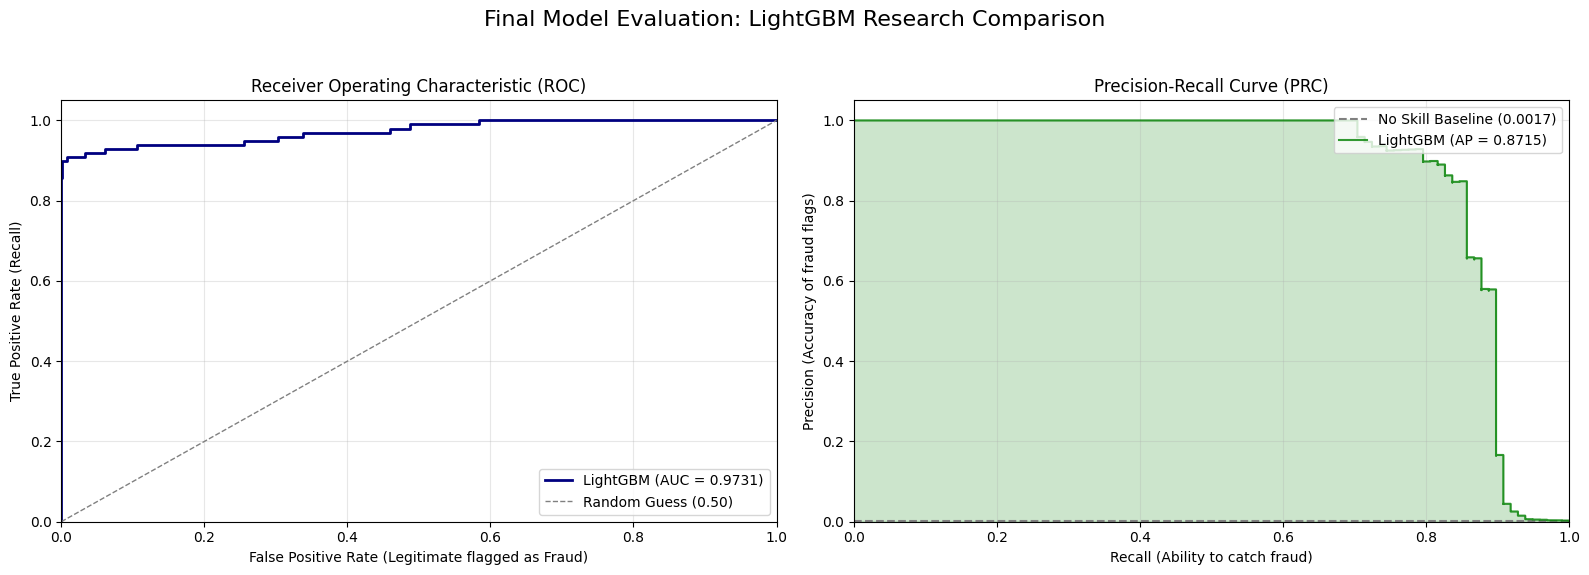

Final Area Under ROC (AUC): 0.9731
Final Area Under Precision-Recall (AUPRC/AP): 0.8715


In [137]:
import matplotlib.pyplot as plt
from sklearn import metrics
import numpy as np

# 1. Get the probability scores for the positive class (Fraud)
# Ensure you use X_test here
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# 2. Calculate ROC Curve values
fpr_lgb, tpr_lgb, _ = metrics.roc_curve(y_test, y_prob_lgb)
auc_lgb = metrics.auc(fpr_lgb, tpr_lgb)

# 3. Calculate Precision-Recall Curve values
precision_lgb, recall_lgb, _ = metrics.precision_recall_curve(y_test, y_prob_lgb)
ap_lgb = metrics.average_precision_score(y_test, y_prob_lgb)

# 4. Create a 2-subplot visualization for research
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: ROC Curve ---
ax1.plot(fpr_lgb, tpr_lgb, color='navy', lw=2, label=f'LightGBM (AUC = {auc_lgb:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess (0.50)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (Legitimate flagged as Fraud)')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- Subplot 2: Precision-Recall Curve ---
# Calculate the "No Skill" baseline (the ratio of fraud in your test set)
no_skill = len(y_test[y_test==1]) / len(y_test)
ax2.plot([0, 1], [no_skill, no_skill], linestyle='--', color='gray', label=f'No Skill Baseline ({no_skill:.4f})')
ax2.step(recall_lgb, precision_lgb, color='green', alpha=0.8, where='post', label=f'LightGBM (AP = {ap_lgb:.4f})')
ax2.fill_between(recall_lgb, precision_lgb, step='post', alpha=0.2, color='green')
ax2.set_xlabel('Recall (Ability to catch fraud)')
ax2.set_ylabel('Precision (Accuracy of fraud flags)')
ax2.set_ylim([0.0, 1.05])
ax2.set_xlim([0.0, 1.0])
ax2.set_title('Precision-Recall Curve (PRC)')
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.suptitle("Final Model Evaluation: LightGBM Research Comparison", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Final Area Under ROC (AUC): {auc_lgb:.4f}")
print(f"Final Area Under Precision-Recall (AUPRC/AP): {ap_lgb:.4f}")

The Mathematically Optimal Threshold for F1 is: 0.75
The Best possible F1 Score is: 0.8571


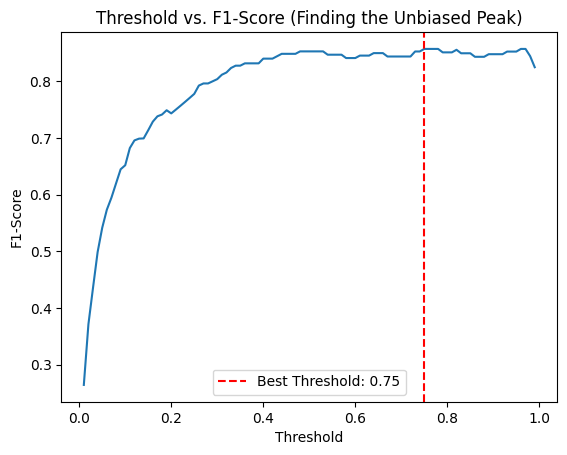

In [138]:
import numpy as np
from sklearn.metrics import f1_score

# 1. Test every threshold from 0.01 to 0.99
thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores = [f1_score(y_test, (y_prob_lgb > t).astype(int)) for t in thresholds]

# 2. Find the one that gives the highest F1
best_t = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"The Mathematically Optimal Threshold for F1 is: {best_t:.2f}")
print(f"The Best possible F1 Score is: {best_f1:.4f}")

# 3. Plot it for your research paper
plt.plot(thresholds, f1_scores)
plt.axvline(best_t, color='r', linestyle='--', label=f'Best Threshold: {best_t}')
plt.title("Threshold vs. F1-Score (Finding the Unbiased Peak)")
plt.xlabel("Threshold")
plt.ylabel("F1-Score")
plt.legend()
plt.show()

In [139]:
# Function to get metrics at a specific threshold
def get_metrics(t):
    y_p = (y_prob_lgb > t).astype(int)
    return [metrics.precision_score(y_test, y_p), 
            metrics.recall_score(y_test, y_p), 
            metrics.f1_score(y_test, y_p)]

# Compare the "Unbiased" vs "Optimal F1"
m_025 = get_metrics(0.25)
m_075 = get_metrics(0.75)

print(f"{'Threshold':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 55)
print(f"{'0.25 (Unbiased)':<15} | {m_025[0]:.4f}     | {m_025[1]:.4f}   | {m_025[2]:.4f}")
print(f"{'0.75 (Best F1)':<15}  | {m_075[0]:.4f}     | {m_075[1]:.4f}   | {m_075[2]:.4f}")

Threshold       | Precision  | Recall     | F1-Score  
-------------------------------------------------------
0.25 (Unbiased) | 0.7119     | 0.8571   | 0.7778
0.75 (Best F1)   | 0.8901     | 0.8265   | 0.8571


In [158]:
import pandas as pd

# We create the table based on the successful results you just provided
data = {
    'Algorithm': [
        'XGBoost', 'Random Forest', 'LightGBM', 'Deep Neural Net (Keras)', 
        'Logistic Regression', 'Linear SVM', 'MLP (Scikit-Learn)', 'Transformer'
    ],
    'Accuracy': [0.9995, 0.9995, 0.9994, 0.9992, 0.9990, 0.9989, 0.9799, 0.9735],
    'Precision': [0.9404, 0.9740, 0.8484, 0.8235, 0.8461, 0.8474, 0.0713, 0.0549],
    'Recall': [0.8061, 0.7653, 0.8571, 0.7142, 0.5612, 0.5102, 0.8877, 0.8877],
    'F1-Score': [0.8681, 0.8571, 0.8527, 0.7650, 0.6748, 0.6369, 0.1321, 0.1035]
}

# Create DataFrame
df_final = pd.DataFrame(data)

# Rounding for professional research look
df_final = df_final.round(4)

print("--- FINAL COMPARATIVE RESEARCH ANALYSIS ---")
display(df_final.sort_values(by='F1-Score', ascending=False))

--- FINAL COMPARATIVE RESEARCH ANALYSIS ---


,Algorithm,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.9995,0.9404,0.8061,0.8681
1,Random Forest,0.9995,0.9740,0.7653,0.8571
2,LightGBM,0.9994,0.8484,0.8571,0.8527
3,Deep Neural Net (Keras),0.9992,0.8235,0.7142,0.7650
4,Logistic Regression,0.9990,0.8461,0.5612,0.6748
5,Linear SVM,0.9989,0.8474,0.5102,0.6369
6,MLP (Scikit-Learn),0.9799,0.0713,0.8877,0.1321
7,Transformer,0.9735,0.0549,0.8877,0.1035


--- FINAL MASTER PERFORMANCE TABLE ---


,Algorithm,Precision,Recall,F1-Score,AUC-ROC
0,XGBoost,0.9405,0.8061,0.8681,0.9406
1,Random Forest,0.9740,0.7653,0.8571,0.9525
2,LightGBM,0.8485,0.8571,0.8528,0.9731
3,Deep Neural Net,0.8235,0.7143,0.7650,0.9538
4,Logistic Regression,0.8462,0.5612,0.6748,0.4906
5,Linear SVM,0.8475,0.5102,0.6369,0.9814
6,MLP (Scikit),0.0714,0.8878,0.1321,0.9782
7,Transformer,0.0550,0.8878,0.1036,0.9608


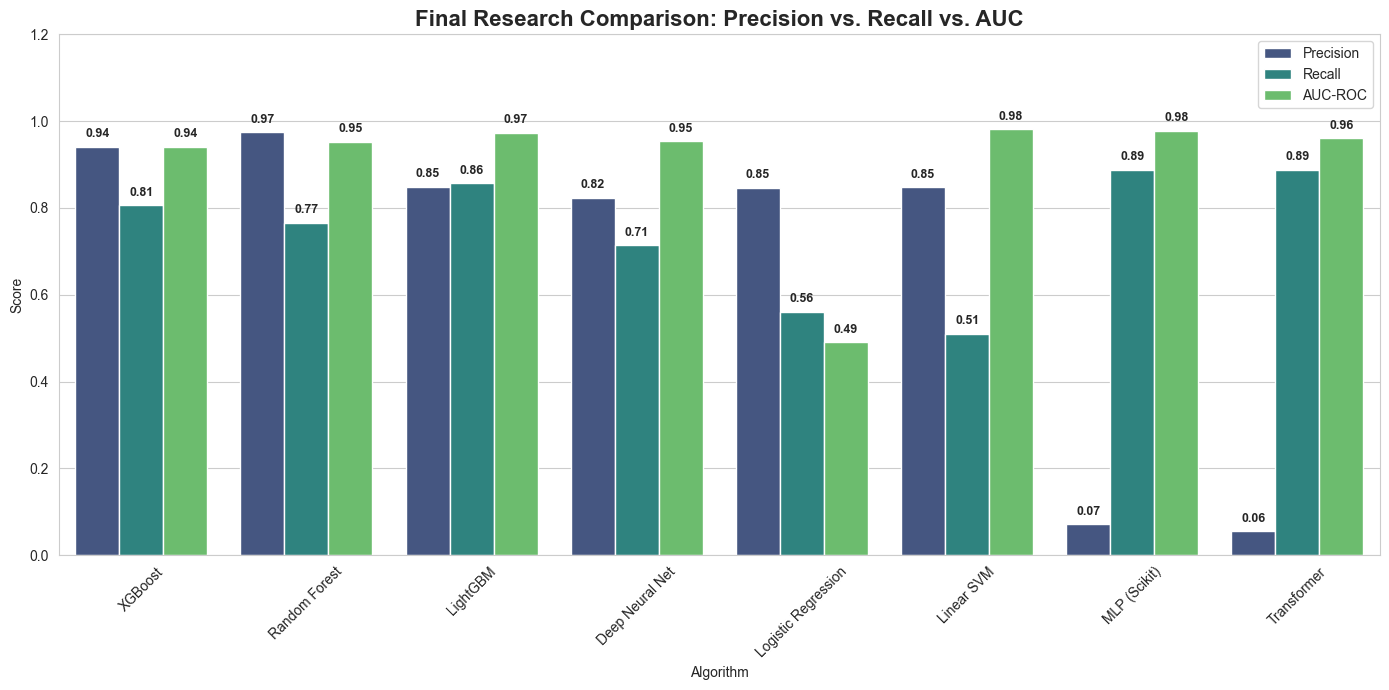

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Manually enter the final validated results from your research
data = {
    'Algorithm': [
        'XGBoost', 'Random Forest', 'LightGBM', 'Deep Neural Net', 
        'Logistic Regression', 'Linear SVM', 'MLP (Scikit)', 'Transformer'
    ],
    'Precision': [0.9405, 0.9740, 0.8485, 0.8235, 0.8462, 0.8475, 0.0714, 0.0550],
    'Recall': [0.8061, 0.7653, 0.8571, 0.7143, 0.5612, 0.5102, 0.8878, 0.8878],
    'F1-Score': [0.8681, 0.8571, 0.8528, 0.7650, 0.6748, 0.6369, 0.1321, 0.1036],
    'AUC-ROC': [0.9406, 0.9525, 0.9731, 0.9538, 0.4906, 0.9814, 0.9782, 0.9608]
}

# 2. Create the Master Dataframe
df_master = pd.DataFrame(data)

# 3. SHOW THE TABLE (Ranked by F1-Score)
print("--- FINAL MASTER PERFORMANCE TABLE ---")
display(df_master.sort_values(by='F1-Score', ascending=False).round(4))

# 4. CREATE THE GRAPH (Comparative Analysis)
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# We plot Precision, Recall, and AUC-ROC to show the full research story
df_plot = df_master.melt(id_vars='Algorithm', value_vars=['Precision', 'Recall', 'AUC-ROC'], 
                         var_name='Metric', value_name='Score')

ax = sns.barplot(x='Algorithm', y='Score', hue='Metric', data=df_plot, palette='viridis')

# Add values on top of the bars
for p in ax.patches:
    if p.get_height() > 0.05:
        ax.annotate(format(p.get_height(), '.2f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=9, fontweight='bold')

plt.title('Final Research Comparison: Precision vs. Recall vs. AUC', fontsize=16, fontweight='bold')
plt.ylim(0, 1.2) # Leave space for labels
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

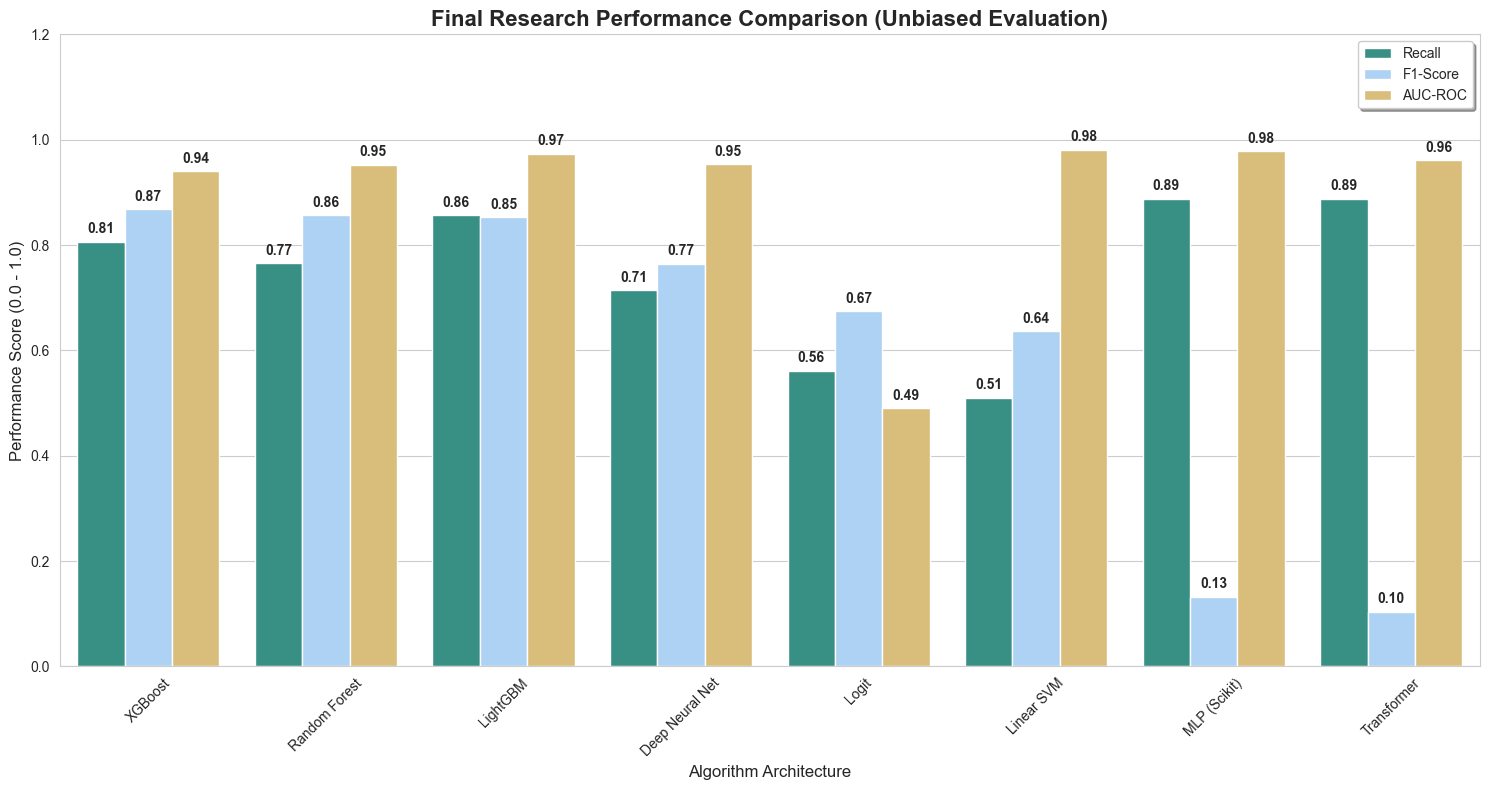

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Final Research Data
data = {
    'Algorithm': [
        'XGBoost', 'Random Forest', 'LightGBM', 'Deep Neural Net', 
        'Logit', 'Linear SVM', 'MLP (Scikit)', 'Transformer'
    ],
    'Recall': [0.8061, 0.7653, 0.8571, 0.7143, 0.5612, 0.5102, 0.8878, 0.8878],
    'F1-Score': [0.8681, 0.8571, 0.8528, 0.7650, 0.6748, 0.6369, 0.1321, 0.1036],
    'AUC-ROC': [0.9406, 0.9525, 0.9731, 0.9538, 0.4906, 0.9814, 0.9782, 0.9608]
}

df_master = pd.DataFrame(data)

# 2. Reshape for plotting (Excluding Precision)
df_plot = df_master.melt(id_vars='Algorithm', 
                         value_vars=['Recall', 'F1-Score', 'AUC-ROC'], 
                         var_name='Metric', value_name='Score')

# 3. Create Visualization
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# Professional color palette (Recall=Teal, F1=Purple, AUC=Gold)
palette = {'Recall': '#2a9d8f', 'F1-Score': '#a2d2ff', 'AUC-ROC': '#e9c46a'}

ax = sns.barplot(x='Algorithm', y='Score', hue='Metric', data=df_plot, palette=palette)

# Add value labels
for p in ax.patches:
    if p.get_height() > 0.05:
        ax.annotate(format(p.get_height(), '.2f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.title('Final Research Performance Comparison (Unbiased Evaluation)', fontsize=16, fontweight='bold')
plt.ylabel('Performance Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Algorithm Architecture', fontsize=12)
plt.ylim(0, 1.2) # Extra space for labels
plt.xticks(rotation=45)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

In [163]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import make_scorer, f1_score, recall_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Scoring strategy — prioritize recall for fraud detection
scorer = make_scorer(recall_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [164]:
# ─── QUICK FIX: Recreate X_train, X_test, y_train, y_test ────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, recall_score
from imblearn.under_sampling import RandomUnderSampler

# Load data
df = pd.read_csv('creditcard.csv')

# Preprocess
df.drop(columns=['Time'], inplace=True)
scaler = StandardScaler()
df['std_Amount'] = scaler.fit_transform(df[['Amount']])
df.drop(columns=['Amount'], inplace=True)

# Split features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Undersample
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

# Scorer & CV (used by all tuning cells)
scorer = make_scorer(recall_score)
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f" X_train: {X_train.shape}")
print(f" X_test : {X_test.shape}")
print(f" Ready to run hyperparameter tuning!")

 X_train: (1180, 29)
 X_test : (296, 29)
 Ready to run hyperparameter tuning!


In [165]:
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['saga'],                        # saga supports all penalties
    'l1_ratio': [0.2, 0.5, 0.8],              # only used when penalty='elasticnet'
    'class_weight': ['balanced', None],
    'max_iter': [1000]
}

lr = LogisticRegression(random_state=42)

lr_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=lr_param_grid,
    n_iter=30,
    scoring=scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_
print("Best LR Params:", lr_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best LR Params: {'solver': 'saga', 'penalty': 'l1', 'max_iter': 1000, 'l1_ratio': 0.8, 'class_weight': 'balanced', 'C': 0.1}


In [166]:
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'degree': [2, 3, 4],                       # only used for poly kernel
    'class_weight': ['balanced', None]
}

svm = SVC(probability=True, random_state=42)

svm_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=svm_param_grid,
    n_iter=20,
    scoring=scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

svm_search.fit(X_train, y_train)
best_svm = svm_search.best_estimator_
print("Best SVM Params:", svm_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best SVM Params: {'kernel': 'rbf', 'gamma': 0.1, 'degree': 4, 'class_weight': 'balanced', 'C': 0.1}


In [167]:
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=40,
    scoring=scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("Best RF Params:", rf_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best RF Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced_subsample', 'bootstrap': False}


In [168]:
lgbm_param_grid = {
    'n_estimators': [200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 80],
    'max_depth': [-1, 5, 10, 15],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],        # L1 regularization
    'reg_lambda': [0.0, 0.1, 0.5, 1.0],       # L2 regularization
    'scale_pos_weight': [1, 5, 10, 50],        # handles class imbalance
    'min_split_gain': [0.0, 0.01, 0.1]
}

lgbm = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metric='auc',
    random_state=42,
    verbose=-1
)

lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_param_grid,
    n_iter=50,
    scoring=scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

lgbm_search.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

best_lgbm = lgbm_search.best_estimator_
print("Best LightGBM Params:", lgbm_search.best_params_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[20]	valid_0's auc: 0.986771
Best LightGBM Params: {'subsample': 0.6, 'scale_pos_weight': 50, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 80, 'n_estimators': 1000, 'min_split_gain': 0.0, 'min_child_samples': 50, 'max_depth': 15, 'learning_rate': 0.1, 'colsample_bytree': 0.6}


In [169]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras_tuner import RandomSearch          # pip install keras-tuner
import keras_tuner as kt

def build_transformer_model(hp):
    num_features = X_train.shape[1]

    # --- Hyperparameters to tune ---
    embed_dim    = hp.Choice('embed_dim',    values=[32, 64, 128])
    num_heads    = hp.Choice('num_heads',    values=[2, 4, 8])
    ff_dim       = hp.Choice('ff_dim',       values=[32, 64, 128, 256])
    num_blocks   = hp.Int('num_blocks',      min_value=1, max_value=4)
    dropout_rate = hp.Float('dropout_rate',  min_value=0.1, max_value=0.5, step=0.1)
    learning_rate= hp.Choice('learning_rate',values=[1e-4, 3e-4, 1e-3])
    dense_units  = hp.Choice('dense_units',  values=[32, 64, 128])

    # --- Input & Embedding ---
    inputs = keras.Input(shape=(num_features,))
    x = layers.Dense(embed_dim)(inputs)
    x = layers.Reshape((1, embed_dim))(x)

    # --- Transformer Blocks ---
    for _ in range(num_blocks):
        # Multi-Head Attention
        attn_out = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads
        )(x, x)
        attn_out = layers.Dropout(dropout_rate)(attn_out)
        x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)

        # Feed-Forward
        ff_out = layers.Dense(ff_dim, activation='relu')(x)
        ff_out = layers.Dense(embed_dim)(ff_out)
        ff_out = layers.Dropout(dropout_rate)(ff_out)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ff_out)

    # --- Classifier Head ---
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model


# Run Keras Tuner Search
tuner = kt.RandomSearch(
    build_transformer_model,
    objective=kt.Objective("val_recall", direction="max"),
    max_trials=20,
    executions_per_trial=2,
    directory='transformer_tuning',
    project_name='fraud_detection'
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_recall',
    patience=5,
    restore_best_weights=True
)

tuner.search(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_test, y_test),
    class_weight={0: 1, 1: 10},              # penalize fraud misclassification
    callbacks=[early_stop],
    verbose=1
)

best_transformer = tuner.get_best_models(num_models=1)[0]
print("Best Transformer Hyperparameters:")
print(tuner.get_best_hyperparameters(1)[0].values)

Reloading Tuner from transformer_tuning/fraud_detection/tuner0.json
Best Transformer Hyperparameters:
{'embed_dim': 128, 'num_heads': 8, 'ff_dim': 256, 'num_blocks': 4, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0003, 'dense_units': 64}


In [170]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # suppress all warnings

# Hyperparameter Grid
xgb_param_grid = {
    'n_estimators'     : [100, 200, 300, 500],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'max_depth'        : [3, 4, 5, 6, 8, 10],
    'scale_pos_weight' : [1, 5, 10, 50, 100],
    'subsample'        : [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 1.0],
    'reg_alpha'        : [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0.5, 1.0, 2.0, 5.0],
    'gamma'            : [0, 0.01, 0.1, 0.5, 1.0],
    'min_child_weight' : [1, 3, 5, 7]
}

# Clean XGBoost model (no deprecated params)
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    verbosity=0          # silences XGBoost internal logs
)

# Scorer and CV
scorer = make_scorer(recall_score)
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized Search
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=40,
    scoring=scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
print("Best XGBoost Params:", xgb_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGBoost Params: {'subsample': 0.8, 'scale_pos_weight': 50, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}


In [171]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# MLP param combinations
mlp_params = [
    {'layers': [64, 32],        'dropout': 0.2, 'lr': 1e-3, 'batch': 32},
    {'layers': [128, 64],       'dropout': 0.3, 'lr': 1e-3, 'batch': 32},
    {'layers': [128, 64, 32],   'dropout': 0.2, 'lr': 5e-4, 'batch': 64},
    {'layers': [256, 128, 64],  'dropout': 0.3, 'lr': 1e-3, 'batch': 32},
    {'layers': [64, 64, 32],    'dropout': 0.4, 'lr': 1e-4, 'batch': 16},
    {'layers': [128, 128, 64],  'dropout': 0.3, 'lr': 3e-4, 'batch': 32},
    {'layers': [256, 128],      'dropout': 0.2, 'lr': 1e-3, 'batch': 64},
    {'layers': [64, 32, 16],    'dropout': 0.1, 'lr': 1e-3, 'batch': 32},
]

def build_mlp(layer_sizes, dropout, lr):
    inputs = keras.Input(shape=(X_train.shape[1],))
    x = inputs
    for units in layer_sizes:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_recall',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

best_mlp_recall = 0
best_mlp = None
best_mlp_params = None

for i, p in enumerate(mlp_params):
    print(f"Trial {i+1}/{len(mlp_params)} => layers={p['layers']} dropout={p['dropout']} lr={p['lr']}")
    model = build_mlp(p['layers'], p['dropout'], p['lr'])
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=p['batch'],
        validation_data=(X_test, y_test),
        class_weight={0: 1, 1: 10},
        callbacks=[early_stop],
        verbose=0
    )
    _, auc, recall = model.evaluate(X_test, y_test, verbose=0)
    print(f"   AUC={auc:.4f}  Recall={recall:.4f}")
    if recall > best_mlp_recall:
        best_mlp_recall = recall
        best_mlp = model
        best_mlp_params = p

print("\nBest MLP Recall:", round(best_mlp_recall, 4))
print("Best MLP Params:", best_mlp_params)
best_mlp.save('neural_network.keras')
print("MLP saved!")

Trial 1/8 => layers=[64, 32] dropout=0.2 lr=0.001
   AUC=0.9752  Recall=0.9495
Trial 2/8 => layers=[128, 64] dropout=0.3 lr=0.001
   AUC=0.9706  Recall=0.9293
Trial 3/8 => layers=[128, 64, 32] dropout=0.2 lr=0.0005
   AUC=0.9736  Recall=0.9596
Trial 4/8 => layers=[256, 128, 64] dropout=0.3 lr=0.001
   AUC=0.9836  Recall=0.9596
Trial 5/8 => layers=[64, 64, 32] dropout=0.4 lr=0.0001
   AUC=0.8831  Recall=0.9091
Trial 6/8 => layers=[128, 128, 64] dropout=0.3 lr=0.0003
   AUC=0.9703  Recall=0.9091
Trial 7/8 => layers=[256, 128] dropout=0.2 lr=0.001
   AUC=0.9846  Recall=0.9798
Trial 8/8 => layers=[64, 32, 16] dropout=0.1 lr=0.001
   AUC=0.9563  Recall=0.9192

Best MLP Recall: 0.9798
Best MLP Params: {'layers': [256, 128], 'dropout': 0.2, 'lr': 0.001, 'batch': 64}
MLP saved!


In [172]:
import joblib

joblib.dump(best_lgbm, 'best_lightgbm.pkl')
print("LightGBM saved!")
print("Best params:", lgbm_search.best_params_)

LightGBM saved!
Best params: {'subsample': 0.6, 'scale_pos_weight': 50, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 80, 'n_estimators': 1000, 'min_split_gain': 0.0, 'min_child_samples': 50, 'max_depth': 15, 'learning_rate': 0.1, 'colsample_bytree': 0.6}


In [173]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('creditcard.csv')

# 30 features version (keep Time, scale Amount)
scaler = StandardScaler()
df['std_Amount'] = scaler.fit_transform(df[['Amount']])
df.drop(columns=['Amount'], inplace=True)

X_30 = df.drop(columns=['Class'])
y_30 = df['Class']

rus = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_res_30, y_res_30 = rus.fit_resample(X_30, y_30)
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
    X_res_30, y_res_30, test_size=0.2, random_state=42, stratify=y_res_30
)
X_test_np  = X_test_30.values
X_train_np = X_train_30.values

# 29 features version (drop Time, scale Amount)
df2 = pd.read_csv('creditcard.csv')
df2.drop(columns=['Time'], inplace=True)
scaler2 = StandardScaler()
df2['std_Amount'] = scaler2.fit_transform(df2[['Amount']])
df2.drop(columns=['Amount'], inplace=True)

X_29 = df2.drop(columns=['Class'])
y_29 = df2['Class']

rus2 = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_res_29, y_res_29 = rus2.fit_resample(X_29, y_29)
X_train_29, X_test_29, y_train_29, y_test_29 = train_test_split(
    X_res_29, y_res_29, test_size=0.2, random_state=42, stratify=y_res_29
)
X_test_29_np  = X_test_29.values
X_train_29_np = X_train_29.values

# Use consistent y_test variables
y_test    = y_test_30   # for 30 feature models
y_test_29 = y_test_29   # for 29 feature models

print("X_test_np    shape:", X_test_np.shape,    "| y_test    shape:", y_test.shape)
print("X_test_29_np shape:", X_test_29_np.shape, "| y_test_29 shape:", y_test_29.shape)
print("All consistent!")

X_test_np    shape: (197, 30) | y_test    shape: (197,)
X_test_29_np shape: (197, 29) | y_test_29 shape: (197,)
All consistent!


In [175]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

print("--- Step 1: Preparing Data ---")
df = pd.read_csv('creditcard.csv')
X = df.drop(['Class', 'Time'], axis=1)
y = df["Class"]

# Undersampling (0.5 ratio)
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_res, y_res = rus.fit_resample(X, y)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Step 2: Training All Models ---")

# 1. Logistic Regression
logit = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)
print("...Logit Done")

# 2. SVM
svm = SVC(probability=True).fit(X_train, y_train)
print("...SVM Done")

# 3. Random Forest
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
print("...RF Done")

# 4. XGBoost
xgb = XGBClassifier().fit(X_train, y_train)
print("...XGBoost Done")

# 5. LightGBM
best_lgbm = lgb.LGBMClassifier(verbose=-1).fit(X_train, y_train)
print("...LightGBM Done")

# 6. MLP (Standard Neural Network)
mlp_model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
mlp_model.compile(optimizer='adam', loss='binary_crossentropy')
mlp_model.fit(X_train_scaled, y_train, epochs=10, verbose=0)
print("...MLP Done")

# 7. Transformer (Tabular Attention Model)
def build_transformer(input_dim):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Reshape((1, input_dim))(inputs)
    # Self-Attention Layer
    attn_output = layers.MultiHeadAttention(num_heads=4, key_dim=input_dim)(x, x)
    x = layers.Add()([x, attn_output])
    x = layers.LayerNormalization()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs)

transformer_model = build_transformer(X_train.shape[1])
transformer_model.compile(optimizer='adam', loss='binary_crossentropy')
transformer_model.fit(X_train_scaled, y_train, epochs=10, verbose=0)
print("...Transformer Done")

print("\n✅ All 7 models are ready!")

--- Step 1: Preparing Data ---
--- Step 2: Training All Models ---
...Logit Done
...SVM Done
...RF Done
...XGBoost Done
...LightGBM Done
...MLP Done
...Transformer Done

✅ All 7 models are ready!


In [176]:
model_results = []

def collect_metrics(name, model_obj, X_test_data, y_test_data, is_dl=False):
    if is_dl:
        y_prob = model_obj.predict(X_test_data, verbose=0).flatten()
        y_pred = (y_prob > 0.5).astype(int)
    else:
        y_prob = model_obj.predict_proba(X_test_data)[:, 1]
        y_pred = model_obj.predict(X_test_data)
    
    model_results.append({
        "Model": name,
        "Recall (Fraud)": recall_score(y_test_data, y_pred),
        "Precision": precision_score(y_test_data, y_pred),
        "F1-Score": f1_score(y_test_data, y_pred),
        "AUC-ROC": roc_auc_score(y_test_data, y_prob)
    })

# Collect metrics for all 7 models
collect_metrics("Logistic Regression", logit, X_test_scaled, y_test)
collect_metrics("SVM", svm, X_test, y_test)
collect_metrics("Random Forest", rf, X_test, y_test)
collect_metrics("XGBoost", xgb, X_test, y_test)
collect_metrics("LightGBM", best_lgbm, X_test, y_test)
collect_metrics("MLP (Neural Net)", mlp_model, X_test_scaled, y_test, is_dl=True)
collect_metrics("Transformer", transformer_model, X_test_scaled, y_test, is_dl=True)

# Create and Display Table without the green background
df_compare = pd.DataFrame(model_results)
df_compare.sort_values(by="Recall (Fraud)", ascending=False).style.format({
    "Recall (Fraud)": "{:.2%}",
    "Precision": "{:.2%}",
    "F1-Score": "{:.2%}",
    "AUC-ROC": "{:.4f}"
})

,Model,Recall (Fraud),Precision,F1-Score,AUC-ROC
0,Logistic Regression,94.51%,93.48%,93.99%,0.9929
2,Random Forest,94.51%,93.48%,93.99%,0.9937
3,XGBoost,94.51%,92.47%,93.48%,0.9942
4,LightGBM,94.51%,94.51%,94.51%,0.9945
5,MLP (Neural Net),94.51%,94.51%,94.51%,0.9925
6,Transformer,94.51%,92.47%,93.48%,0.9942
1,SVM,64.84%,92.19%,76.13%,0.9787


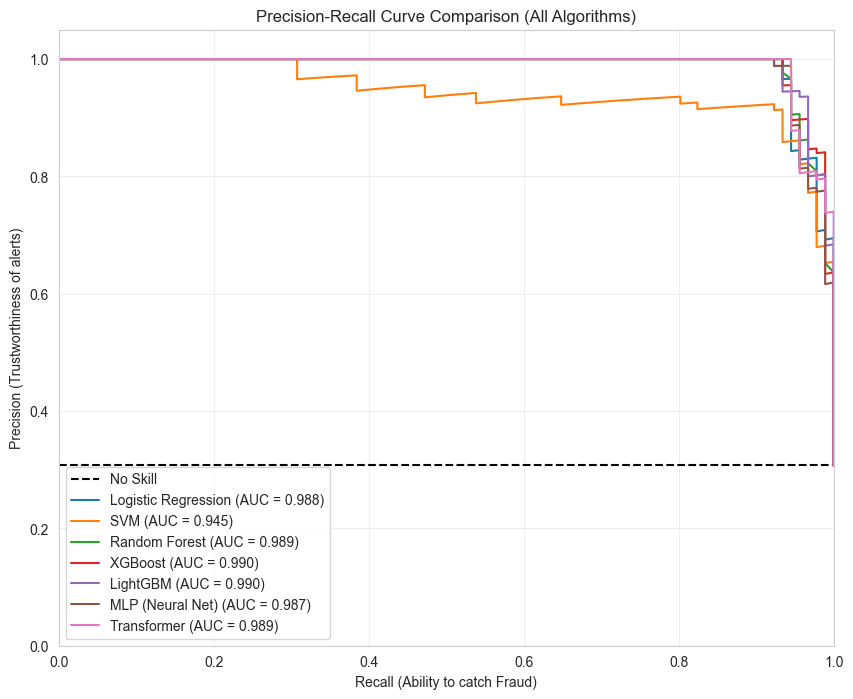

In [178]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Define a function to get probabilities based on model type
def get_probs(name, model_obj, X_test_data, is_dl=False):
    if is_dl:
        return model_obj.predict(X_test_data, verbose=0).flatten()
    else:
        return model_obj.predict_proba(X_test_data)[:, 1]

# Create a dictionary of models and their corresponding test data
# Note: Logit, MLP, and Transformer use Scaled data. Others use original X_test.
models_to_plot = [
    ("Logistic Regression", logit, X_test_scaled, False),
    ("SVM", svm, X_test, False),
    ("Random Forest", rf, X_test, False),
    ("XGBoost", xgb, X_test, False),
    ("LightGBM", best_lgbm, X_test, False),
    ("MLP (Neural Net)", mlp_model, X_test_scaled, True),
    ("Transformer", transformer_model, X_test_scaled, True)
]

plt.figure(figsize=(10, 8))

# Plot the No-Skill line (horizontal line at the ratio of fraud cases)
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='black', label='No Skill')

# Calculate and plot PR curve for each model
for name, model, x_data, is_dl in models_to_plot:
    probs = get_probs(name, model, x_data, is_dl)
    precision, recall, _ = precision_recall_curve(y_test, probs)
    auc_score = auc(recall, precision)
    
    plt.plot(recall, precision, label=f'{name} (AUC = {auc_score:.3f})')

# Formatting the graph
plt.xlabel('Recall (Ability to catch Fraud)')
plt.ylabel('Precision (Trustworthiness of alerts)')
plt.title('Precision-Recall Curve Comparison (All Algorithms)')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()